In [1]:
%pip install cftime netCDF4 xarray gpytorch torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
!groups

users users open nlds-cache-01-o-members


In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
import torch
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern, DotProduct
from sklearn.decomposition import PCA
import math
import torch
from sklearn.metrics import mean_squared_error, r2_score
import gpytorch
import pandas as pd
from sklearn.preprocessing import StandardScaler
import os
import random
import cartopy.crs as ccrs

gpytorch.settings.cholesky_jitter(1e-3) # Increase numerical stability
warnings.filterwarnings("ignore")


def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42) # Forces absolute reproducibility across both CPU and GPU blocks

In [2]:
# working on JASMIN - file paths need to be to CEDA archive; all datasets are unprocessed so be sure to handle this in the next few code blocks
dir_path = "/badc/cmip6/data/CMIP6/" # this is the directory for all cmip6 output

# ------ read ukesm-0-ll data (near-surface temperature, 'tas' diagnostic) ------------
# here, we use r1i1p1f2 ensemble member for testing. Ideally, we would use the mean of all ensemble members.


ssp245_raw_path = dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/tas/gn/files/*/*.nc" 
ssp126_raw_path = dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp126/r1i1p1f2/Amon/tas/gn/files/*/*.nc"
ssp370_raw_path = dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp370/r1i1p1f2/Amon/tas/gn/files/*/*.nc"
ssp585_raw_path = dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/tas/gn/latest/*nc" # 2015-2100 (starting from historical end)
ssp534over_raw_path = dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Amon/tas/gn/latest/*nc" # 2040-2100 (branching from ssp585)
ds_hist_unprocessed_loc = dir_path + "CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/tas/gn/latest/*nc" # 1850-2014 run
ds_hist = xr.open_mfdataset(ds_hist_unprocessed_loc)
days = ds_hist['time'].dt.days_in_month
weights = days.groupby('time.year') / days.groupby('time.year').sum(dim='time')
ds_hist = (ds_hist.get(['tas']) * weights).groupby('time.year').sum(dim='time') 
baseline_ds = ds_hist
master_mean = baseline_ds.sel(year=slice(1850, 1900)).mean('year')

n_lags=10 # used later to build the time-lags - we define it here so that we can select the correct number of years from historical early on

### COMPUTE ANOMALIES for this dataset 
def compute_anomalies(dataset_to_convert, mean_to_use=master_mean):
    dataset_to_convert = (dataset_to_convert - mean_to_use).compute()
    return dataset_to_convert

def process_raw_to_anomalies(raw_dataset):
    """
    Takes in raw dataset (either 1850-2014, 2015-2100, or concatenation) and processes ready for training
    """
    days_test = raw_dataset['time'].dt.days_in_month
    weights_test = days_test.groupby('time.year') / days_test.groupby('time.year').sum(dim='time')
    raw_updated = (raw_dataset.get(['tas']) * weights_test).groupby('time.year').sum(dim='time')
    return compute_anomalies(raw_updated)

### TESTING

def compute_grid_areas(ds, var, x='X', y='Y', RAD_EARTH = 6.387e6):
    """Compute grid-cell areas
    Parameters ==> ds : xarray Dataset for data variables
    Returns ==> Cell_area : grid cell areas"""
    ds = ds.copy()
    dx = np.mean(ds[x].diff(x)) * np.cos(ds[y] * np.pi / 180.) * (2 * np.pi * RAD_EARTH / 360.)
    dy = np.mean(ds[y].diff(y)) * (2 * np.pi * RAD_EARTH / 360.)
    Cell_area = dx * dy
    Cell_area, tmp = xr.broadcast(Cell_area, var)
    return Cell_area

def apply_area_weighting(dataset_test):
    # For global-mean quantities, we first need to compute grid cell areas and then calculate area-weighted mean
    RAD_EARTH = 6.387e6
    for ds in [dataset_test]:
        dA = compute_grid_areas(ds, ds['tas'].isel(year=0),
                                x='lon', y='lat', RAD_EARTH = RAD_EARTH) # grid cell areas for area-integration
        tas_avg = (ds['tas'] *  dA).sum(['lat', 'lon']) / dA.sum(['lat', 'lon'])
        ds['tas_global'] = tas_avg.compute()
    # Transpose the test set so 'year' comes first: (year, lat, lon)
    dataset_test = dataset_test.transpose('year', 'lat', 'lon')
    return dataset_test


ds_ssp245 = process_raw_to_anomalies(xr.open_mfdataset(ssp245_raw_path))

# one of the training sets (low emission)
ds_ssp126 = process_raw_to_anomalies(xr.open_mfdataset(ssp126_raw_path)) # Combine the two parts into one

# another test set to cross-validate with (mid-low emission, no overshoot)
test_ssp370 = process_raw_to_anomalies(xr.open_mfdataset(ssp370_raw_path))

ds_ssp534os = process_raw_to_anomalies(xr.open_mfdataset(ssp534over_raw_path))
ds_ssp585 = process_raw_to_anomalies(xr.open_mfdataset(ssp585_raw_path))

history_timelags = compute_anomalies(ds_hist.sel(year=slice(2015-n_lags+1, 2015-1)))

#dataset_test = process_raw_to_anomalies(ds_ssp245)
dataset_test = ds_ssp534os

if dataset_test == ds_ssp534os:
    # ssp534-os only starts at 2040, using ssp585 from 2015-2039 - we need to prepend those years for the time-lags
    dataset_test = xr.concat([ds_ssp585.sel(year=slice(2040-n_lags+1, 2040-1)), dataset_test], dim='year')
else:
    # other test datasets typically start from 2015 unless we specify otherwise - assume the historical run to 2014 
    dataset_test = xr.concat([history_timelags, dataset_test], dim='year')
dataset_test = apply_area_weighting(dataset_test)
training_sets = [ds_ssp126, ds_ssp585, ds_ssp245]

# we can also specify a validation set to cross-reference with in testing - we shall use ssp370 for now
#validation_set = apply_area_weighting(test_ssp370)
validation_set = apply_area_weighting(xr.concat([history_timelags, test_ssp370], dim='year'))

### Now that each dataset has been converted to anomalies, we need to add the historical subset to the front of each one, including testing
training_sets = [apply_area_weighting(xr.concat([history_timelags, dataset], dim='year')) for dataset in training_sets]

In [3]:
print(training_sets[2].year)
print(dataset_test.year)

<xarray.DataArray 'year' (year: 95)> Size: 760B
array([2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029,
       2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041,
       2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053,
       2054, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065,
       2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077,
       2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089,
       2090, 2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100])
Coordinates:
  * year     (year) int64 760B 2006 2007 2008 2009 2010 ... 2097 2098 2099 2100
<xarray.DataArray 'year' (year: 70)> Size: 560B
array([2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042,
       2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054,
       2055, 2056, 2057, 2

In [4]:
"""
# Calculate full-timeline average global anomaly for the test sets
# - for ssp370, this will be 2015-2100
# - for ssp534-os, this will be 2040-2100
# Next, do same for 2080-2100 
# We need this for the normalisation coefficient for computing an estimate of NRMSE
# - linear baseline and LSTM-GP both compute perfect global anomaly recreation, whereas PCA-GP and CNN-GP are marginally off --> say it is negligible and assume it to be 0
# - we could just compute NRMSE for LSTM-GP as it is the only model to perfectly recreate the global anomaly + our most consistent model
# dataset_test   
# validation_set
# anomalies stored in tas_global
"""
test_full_avg = np.mean(dataset_test.sel(year=slice(2040, 2100)).tas_global)
test_latter_avg = np.mean(dataset_test.sel(year=slice(2080,2100)).tas_global)

val_full_avg = np.mean(validation_set.sel(year=slice(2040, 2100)).tas_global)
val_latter_avg = np.mean(validation_set.sel(year=slice(2015,2100)).tas_global)

print(f"""
SSP534-os
-----------
Full timeline average global anomaly: {test_full_avg}
2080-2100 average global anomaly >>>: {test_latter_avg}
===========
SSP370
-----------
Full timeline average global anomaly: {val_full_avg}
2080-2100 average global anomaly >>>: {val_latter_avg}
""")


SSP534-os
-----------
Full timeline average global anomaly: <xarray.DataArray 'tas_global' ()> Size: 8B
array(3.42068166)
2080-2100 average global anomaly >>>: <xarray.DataArray 'tas_global' ()> Size: 8B
array(3.51083743)
SSP370
-----------
Full timeline average global anomaly: <xarray.DataArray 'tas_global' ()> Size: 8B
array(4.17069405)
2080-2100 average global anomaly >>>: <xarray.DataArray 'tas_global' ()> Size: 8B
array(3.47074978)



In [6]:
def remove_global_trend_prior_to_pca(train_set):
    # 1. Compute the physically accurate area-weighted global mean and attach it
    # This also guarantees the correct (year, lat, lon) dimension transposition
    trainset_weighted = apply_area_weighting(train_set)
    
    # 2. Subtract the 1D area-weighted timeline from the 3D spatial map
    zero_global_mean_spatial_grid = trainset_weighted.tas - trainset_weighted.tas_global
    
    # 3. Flatten the remaining zero-global-mean grid and save it
    flat_grid = zero_global_mean_spatial_grid.values.reshape(len(trainset_weighted.year), -1)
    return flat_grid

# --- REMOVE GLOBAL TREND PRIOR TO PCA (WITH AREA WEIGHTING) ---
spatial_anomalies_sets = []

for trainset in training_sets:
    spatial_anomalies_sets.append(remove_global_trend_prior_to_pca(trainset))

# also need to apply to historical anomalies ### TODO - once raw history up to 2014 has been processed, find anomalies as shown here
### THIS IS SORTED - we natively add historical years

Number of PCs chosen: 9
Shape of coefficients for GP: (285, 9)


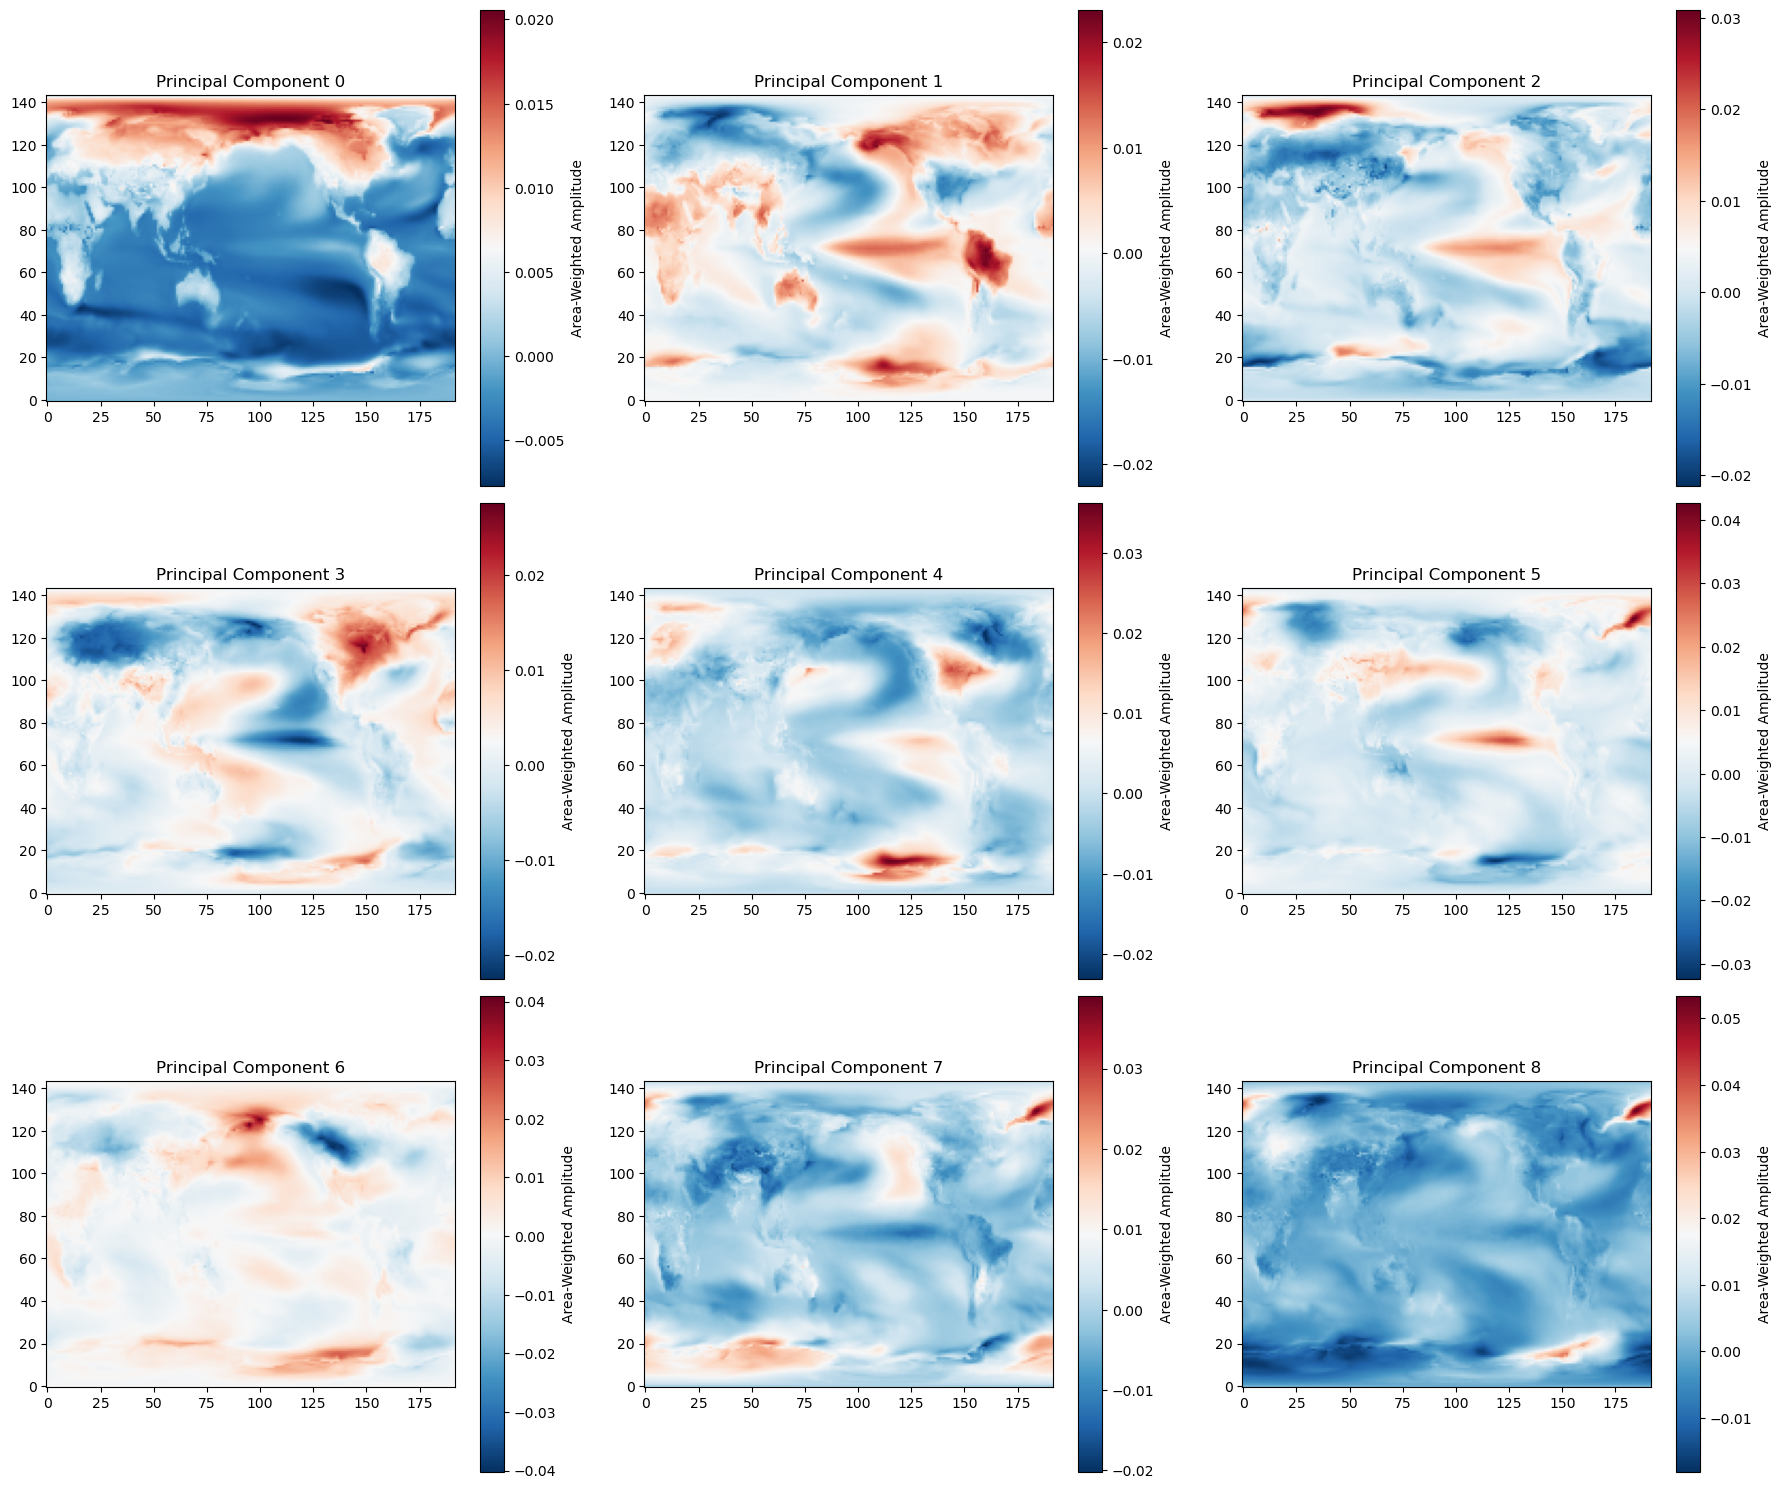

In [7]:
# =========================================================
# FIXED PCA FUNCTION (Includes Latitude Cosine Weighting)
# =========================================================
def get_pcas(data_2d, latitudes, n_components=0.8, plot_pcs=True):
    """
    Accepts pre-stacked 2D numpy grid arrays (Years, Spatial_Points) and latitude vector.
    Scales features geometrically using cosine weighting, runs PCA, and returns weights.
    """
    # 1. CREATE AREA WEIGHTS: (144, 192) grid map based on physical latitude geometry
    # Cosine of latitude shrinks toward poles. We use sqrt so when variance is computed later (squared),
    # the linear area weight scales perfectly proportional to true geographic surface area.
    weights_1d = np.cos(np.deg2rad(latitudes))
    weights_1d = np.clip(weights_1d, 0, None)  # Safety clip to handle numerical precision at poles
    weights_2d = np.repeat(np.sqrt(weights_1d)[:, np.newaxis], 192, axis=1)
    flat_weights = weights_2d.flatten()          # Shape: (144 * 192,)
    
    # 2. APPLY WEIGHTING: Scale spatial variance naturally
    # Multiply every year's map row by the area weight vector row
    data_scaled = data_2d * flat_weights
    
    # 3. RUN PCA: Fit on the properly weighted spatial grids
    pca = PCA(n_components=n_components)
    pca_coefficients = pca.fit_transform(data_scaled)    
    
    # 4. RECONSTRUCT PATTERNS
    spatial_patterns = pca.components_.reshape(-1, 144, 192)
    
    if plot_pcs:
        print(f"Number of PCs chosen: {pca.n_components_}")
        print(f"Shape of coefficients for GP: {pca_coefficients.shape}")
        n_pcs = len(spatial_patterns)
        cols = 3
        rows = math.ceil(n_pcs / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
        axes = axes.flatten()
        
        for i in range(n_pcs):
            im = axes[i].imshow(spatial_patterns[i], cmap='RdBu_r', origin='lower')
            axes[i].set_title(f'Principal Component {i}')
            plt.colorbar(im, ax=axes[i], label='Area-Weighted Amplitude')
            
        for j in range(n_pcs, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()
        
    return flat_weights, pca, pca_coefficients

# 1. Stack raw spatial inputs vertically
if hasattr(spatial_anomalies_sets[0], 'tas'):
    stacked = np.vstack([ds.tas.values.reshape(len(ds.tas['year']), -1) for ds in spatial_anomalies_sets])
    # Extract the 144 latitude values from your training structures
    latitudes = spatial_anomalies_sets[0].lat.values 
else:
    stacked = np.vstack(spatial_anomalies_sets)
    latitudes = np.linspace(-90, 90, 144) # Fallback if data is raw numpy

# 2. Get PCA patterns - NOW RETURNS THE GEOGRAPHIC WEIGHT VECTOR INSTEAD OF SCALER
flat_weights, pcas, pca_coefficients = get_pcas(stacked, latitudes, n_components=0.8, plot_pcs=True)

# 3. Convert training scenarios to global mean values for X inputs
combined_x = np.concatenate(
    #[ds.tas.mean(dim=['lat','lon']).values for ds in training_sets]
    [ds.tas_global.values for ds in training_sets]
).reshape(-1, 1)


#4. dont scale x yet - do scaling just before the model training

# 5. Handle targets (Y PCA coefficients)
all_y_scaled = pca_coefficients 


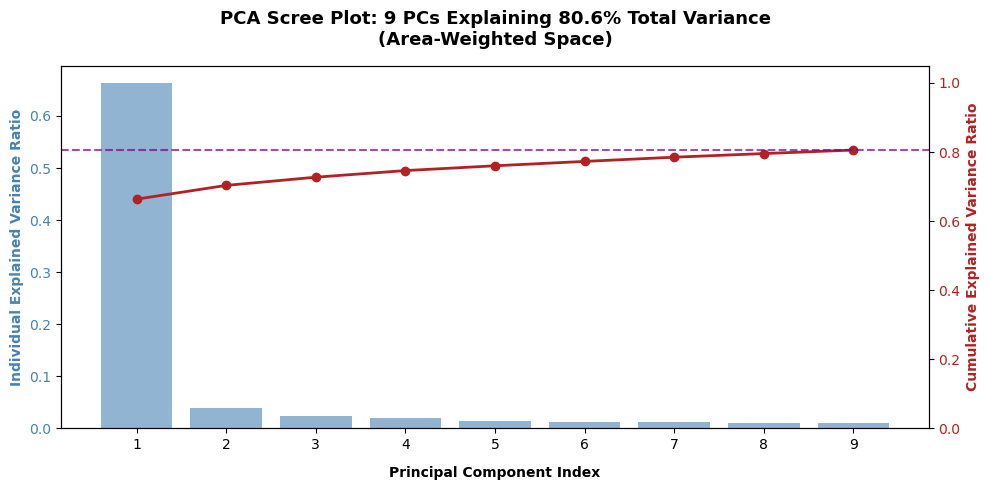

In [8]:
# Let us visualise the contributions of each principal component to explained variance
# =========================================================
# --- PCA SCREE PLOT VISUALIZATION ---
# =========================================================

# 1. Extract variance data directly from your fitted 'pcas' object
exp_var_ind = pcas.explained_variance_ratio_
exp_var_cum = np.cumsum(exp_var_ind)
num_comps_chosen = pcas.n_components_

# 2. Setup indices for the x-axis
components_x = np.arange(1, num_comps_chosen + 1)

# 3. Create dual-axis subplot
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- PRIMARY Y-AXIS: Individual Explained Variance (Bars) ---
color_bar = 'steelblue'
ax1.set_xlabel('Principal Component Index', fontweight='bold', labelpad=10)
ax1.set_ylabel('Individual Explained Variance Ratio', color=color_bar, fontweight='bold')
bars = ax1.bar(components_x, exp_var_ind, color=color_bar, alpha=0.6, label='Individual Variance')
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.set_xticks(components_x)  # Enforce clear integers on the ticks index

# --- SECONDARY Y-AXIS: Cumulative Explained Variance (Line) ---
ax2 = ax1.twinx()  
color_line = 'firebrick'
ax2.set_ylabel('Cumulative Explained Variance Ratio', color=color_line, fontweight='bold')
line = ax2.plot(components_x, exp_var_cum, color=color_line, marker='o', linewidth=2, label='Cumulative Variance')
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 1.05)  # Constrain bounds cleanly to percentage scale

# 4. Add visual target anchors to track your 80% threshold
target_threshold = np.sum(exp_var_ind) # Will exactly match your n_components configuration (e.g., 0.8)
ax2.axhline(y=target_threshold, color='purple', linestyle='--', alpha=0.7, 
            label=f'Target Threshold ({target_threshold*100:.0f}%)')

# 5. Clean layout adjustments
plt.title(f'PCA Scree Plot: {num_comps_chosen} PCs Explaining {target_threshold*100:.1f}% Total Variance\n(Area-Weighted Space)', 
          fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()


Now, we want to create temporal windows, i.e. each row isn't just a year, but a year with the previous n years before it included, so that points aren't just spatially resolved by the PCA but also temporally - a key drawback to the GP in ClimateBench was this lack of temporal resolution for the GP.

First, fit PCA on combined stack of scenarios using the same basis.

Next, we need to apply StandardScaler to each scenario's x and y PCA values separately to get in the same range ready for machine learning.

Then, we need to generate the temporal lags for each scaled scenario.

After, we can concatenate them safely into one big dataset.

In [9]:
# =========================================================
# STEP 2: SPLIT BACK TO SCENARIOS TO BUILD LAGS SAFELY
# =========================================================
years_per_scenario = [len(scenario.year) for scenario in training_sets]
#print(years_per_scenario)

scaled_sets_x = []
scaled_sets_y = []
current_index = 0
for i in range(0, len(years_per_scenario)):
    if i == 0:
        current_index = 0
        next_index = years_per_scenario[i]
    else:
        current_index = next_index
        next_index = current_index + years_per_scenario[i]
    scaled_sets_x.append(combined_x[current_index:next_index]) # x is not scaled just yet
    scaled_sets_y.append(all_y_scaled[current_index:next_index])
    #print(current_index, next_index)

def build_lagged_dataset(scaled_x, scaled_y, n_lags=3, add_historical_years=True):
    """
    Creates temporal lag features for a single continuous scenario timeline.
    
    Parameters:
    - scaled_x: NumPy array of shape (Years, 1) containing global mean features.
    - scaled_y: NumPy array of shape (Years, Num_PCs) containing target coefficients.
    - n_lags: Total length of the lookback window (e.g., 3 handles t, t-1, t-2).
    - add_historical_years: if True, we need to prepend years of historical anomalies,
                            so that when we trim the data to have full lags, we have all the intended years.
                            i.e. if we have n_lags=10, we lose the first 10 years of the dataset --> not good;
                            ==> our scenarios start with 2015-2049; just take n_lags years from the end of 
                            historical anomalies and prepend before we calculate time lags.
    """
    historical_prepend = "" #### TODO - define the spatial anomaly years to use using n_lags - THIS IS SORTED ABOVE WHERE WE NATIVELY PREPEND HISTORICAL
    ### rest of code should smoothly handle this change

    
    num_years = len(scaled_x)
    
    # Storage for the transformed matrices
    lagged_x_list = []
    sliced_y_list = []
    
    # Start the loop after the lag buffer to ensure history exists
    for t in range(n_lags - 1, num_years):
        # 1. Harvest the lookback window from (t - lags + 1) up to and including (t)
        # For n_lags=3, this grabs rows at indices [t-2, t-1, t]
        time_window = scaled_x[t - n_lags + 1 : t + 1]
        
        # 2. Flatten the window horizontally from a 2D matrix into a 1D vector row
        # (e.g., shape (3, 1) becomes a flat row array of shape (3,))
        flat_row = time_window.flatten()
        lagged_x_list.append(flat_row)
        
        # 3. Match it with the target coefficients corresponding strictly to year (t)
        sliced_y_list.append(scaled_y[t])
        
    return np.array(lagged_x_list), np.array(sliced_y_list)

# Create temporary lists to collect the rows from every scenario
all_scenarios_x = []
all_scenarios_y = []


# 1. Run the lagging function across all pairs at once
processed_pairs = [build_lagged_dataset(x, y, n_lags=n_lags) for x, y in zip(scaled_sets_x, scaled_sets_y)]

# 2. Extract and stack the raw X lag matrices vertically
raw_train_x_stacked = np.vstack([pair[0] for pair in processed_pairs])

# 3. FIT AND TRANSFORM THE SCALER HERE (The Final Fix!)
scaler_x = StandardScaler()
scaled_train_x_stacked = scaler_x.fit_transform(raw_train_x_stacked)

# 4. Convert both to clean PyTorch Tensors for your Batch GP
train_x = torch.tensor(scaled_train_x_stacked).float()
train_y = torch.tensor(np.vstack([pair[1] for pair in processed_pairs])).float()

# Verify your final shapes match the Batch GP expectations
print(f"Final combined train_x shape: {train_x.shape}") # Expect: (Total_Valid_Years, n_lags)
print(f"Final combined train_y shape: {train_y.shape}") # Expect: (Total_Valid_Years, Num_PCs)
print("First 5 rows of train_x - check it looks as expected")
print(train_x[:5])


Final combined train_x shape: torch.Size([258, 10])
Final combined train_y shape: torch.Size([258, 9])
First 5 rows of train_x - check it looks as expected
tensor([[-1.5247, -1.4915, -1.4363, -1.4374, -1.4249, -1.4000, -1.4519, -1.4115,
         -1.3911, -1.3824],
        [-1.4660, -1.4114, -1.4156, -1.4050, -1.3808, -1.4337, -1.3918, -1.3698,
         -1.3626, -1.3707],
        [-1.3855, -1.3906, -1.3830, -1.3605, -1.4148, -1.3731, -1.3498, -1.3411,
         -1.3508, -1.3201],
        [-1.3646, -1.3578, -1.3382, -1.3948, -1.3536, -1.3307, -1.3208, -1.3292,
         -1.2998, -1.2425],
        [-1.3315, -1.3128, -1.3727, -1.3331, -1.3109, -1.3014, -1.3088, -1.2779,
         -1.2215, -1.1357]])


Below, we train our GPs as a batch. This outputs a batch where we have to use indexing to access the relevant GP for each PC, and then for each scenario.

In [10]:
class ClimateGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, input_dims):
        super(ClimateGPModel, self).__init__(train_x, train_y, likelihood)
        num_pcs = train_y.shape[0] 
        pc_batch_shape = torch.Size([num_pcs])
        # 1. MEAN FUNCTION WITH BIAS
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=pc_batch_shape)
        # 2. SHORT-TERM WEATHER / CHAOTIC VARIABILITY KERNEL (ARD Enabled) - automatic relevance determinance
        self.short_term_matern = gpytorch.kernels.MaternKernel(
            nu=1.5, 
            ard_num_dims=input_dims,
            batch_shape=pc_batch_shape,
            lengthscale_constraint=gpytorch.constraints.Interval(0.01, 10.0) 
        )
        self.short_term_scale = gpytorch.kernels.ScaleKernel(
            self.short_term_matern,
            batch_shape=pc_batch_shape
        )
        # 3. SMOOTH DECADAL CYCLE KERNEL (Decoupled and Additive)
        # Nu=2.5 creates much smoother cyclic oscillations (like El Niño/Decadal trends)
        # Multiplying it by Periodic creates locally periodic variations that can change amplitude
        smooth_matern = gpytorch.kernels.MaternKernel(
            nu=2.5,
            batch_shape=pc_batch_shape,
            lengthscale_constraint=gpytorch.constraints.Interval(1.0, 15.0)
        )
        periodic = gpytorch.kernels.PeriodicKernel(
            batch_shape=pc_batch_shape,
            period_length_constraint=gpytorch.constraints.Interval(0.02, 0.5) 
        )
        self.cyclic_scale = gpytorch.kernels.ScaleKernel(
            smooth_matern * periodic,
            batch_shape=pc_batch_shape
        )
        # 4. LONG-TERM BACKGROUND TREND TRUCKER
        # Adding a Linear Kernel lets the model track multi-decadal shifts 
        # cleanly without relying solely on the mean function slope
        self.trend_scale = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.PolynomialKernel(power=2, batch_shape=pc_batch_shape),
            batch_shape=pc_batch_shape
        )
        # Combine the components additively so each handles a distinct physical trend
        self.covar_module = self.short_term_scale + self.cyclic_scale + self.trend_scale

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


In [11]:
num_pcs = pcas.n_components_

# --- 1. DATA PREPARATION (The Dimension Shift) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# train_x comes from lag loop with shape: (Total_Valid_Years, n_lags)
# train_y comes from lag loop with shape: (Total_Valid_Years, 7)

# 1. GPyTorch expects Y to be: [Batch_Size, Num_Samples] -> [7, Total_Valid_Years]
train_y_model = train_y.t().to(device) # Simply transpose the matrix using .t()

# 2. GPyTorch expects X to be: [Batch_Size, Num_Samples, Num_Features] -> [7, Total_Valid_Years, n_lags]
# Add a batch dimension at index 0, then repeat it across all 7 independent PC pipelines
train_x_model = train_x.unsqueeze(0).repeat(num_pcs, 1, 1).to(device)


In [12]:
# =========================================================
# 1. COMPUTE PHYSICAL IMPORTANCE WEIGHTS
# =========================================================
# Extract the variance explained by each of your kept components
variance_ratios = pcas.explained_variance_ratio_[:num_pcs]

# Normalize them so they sum up to 1.0 (maintains stable loss scales)
normalized_weights = variance_ratios / np.sum(variance_ratios)

# Convert to a PyTorch tensor and send to your active hardware device
loss_weights = torch.tensor(normalized_weights).float().to(device)

print("Component loss weights (PC0 down to minor PCs):")
print(loss_weights.cpu().numpy())


# =========================================================
# 2. INITIALIZATION
# =========================================================
# Standard GaussianLikelihood handles the batch dimensions automatically
likelihood = gpytorch.likelihoods.GaussianLikelihood(
    batch_shape=torch.Size([num_pcs]),
    noise_constraint=gpytorch.constraints.GreaterThan(1e-4)
    #noise_constraint=gpytorch.constraints.Interval(1e-4, 0.05)
).to(device)
likelihood.initialize(noise=torch.ones(num_pcs).to(device) * 0.01) # Manually initialize noise to help convergence

model = ClimateGPModel(train_x_model, train_y_model, likelihood, input_dims=n_lags).to(device)

# 1. Initialize Optimizer (Higher LR for faster initial convergence)
optimizer = torch.optim.Adam(model.parameters(), lr=0.5)

# 2. Initialize Scheduler - Added threshold to ensure LR actively drops when progress slows down linearly
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=20,       # Wait 20 epochs of no improvement before cutting
    threshold=0.005,   # Enforce a 0.5% minimum drop to count as real progress
    threshold_mode='rel'
)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model).to(device)


# =========================================================
# 3. TRAINING LOOP WITH WEIGHTED LOSS
# =========================================================
patience = 50
min_delta = 0.0001
best_loss = float('inf')
counter = 0

model.train()
likelihood.train()
epochs = 5000

for i in range(epochs):
    optimizer.zero_grad()
    output = model(train_x_model)
    
    # --- FIXED: WEIGHTED LOSS CALCULATION ---
    # -mll() returns a vector of losses of shape: [num_pcs]
    individual_pc_losses = -mll(output, train_y_model)
    
    # Multiply each component's loss by its physical variance weight, then sum them up
    loss = (individual_pc_losses * loss_weights).sum()
    # ----------------------------------------
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0) # Prevents massive jumps
    optimizer.step()

    # --- STEP THE SCHEDULER ---
    # The scheduler monitors the weighted loss to decide when to drop the LR
    scheduler.step(loss)
    current_lr = optimizer.param_groups[0]['lr'] # Get current LR for logging
    current_loss = loss.item()
    
    if current_loss < best_loss - min_delta:
        best_loss = current_loss
        counter = 0
    else:
        counter += 1
        
    if counter >= patience:
        print(f'Early stopping at iteration {i+1}. Final LR: {current_lr:.6f}')
        break
        
    if i % 100 == 0:
        print(f'Epoch {i+1:04d}/{epochs} - Weighted Average Loss: {current_loss:.3f}; LR: {current_lr:.6f}')

print("Training complete!")


Component loss weights (PC0 down to minor PCs):
[0.8236144  0.04939632 0.02950346 0.02370245 0.01727754 0.01566687
 0.01516403 0.01304035 0.01263459]
Epoch 0001/5000 - Weighted Average Loss: 115.117; LR: 0.500000
Epoch 0101/5000 - Weighted Average Loss: 4.635; LR: 0.500000
Epoch 0201/5000 - Weighted Average Loss: 4.380; LR: 0.500000
Epoch 0301/5000 - Weighted Average Loss: 4.270; LR: 0.250000
Epoch 0401/5000 - Weighted Average Loss: 4.260; LR: 0.007812
Early stopping at iteration 497. Final LR: 0.000244
Training complete!


--- Mask Validation Summary ---
Total Grid Cells (Lat x Lon): 27648
Valid Ocean Cells (True):     18292 (66.2%)
NaN Land Cells (False):       9356


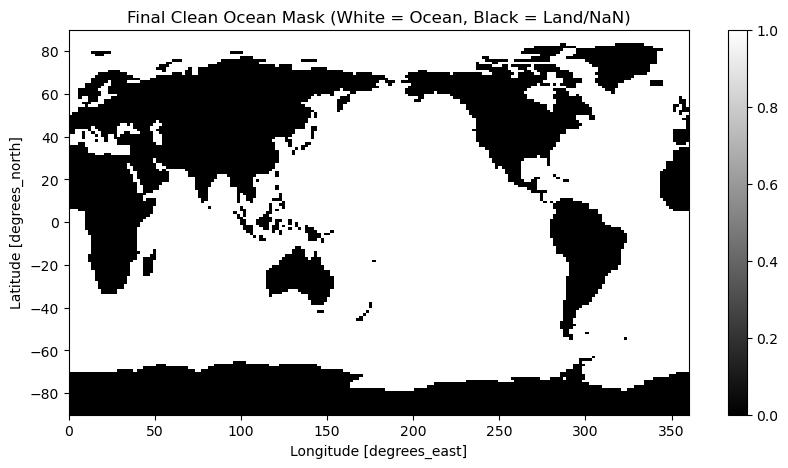

In [13]:
import xesmf as xe
import rioxarray
import regionmask
from shapely.geometry import MultiPolygon, Polygon
from shapely.ops import unary_union
from scipy.ndimage import binary_dilation, zoom
from matplotlib.colors import LinearSegmentedColormap


### These are needed to regrid tos data to the same format as atmospheric grids, as well as extract an ocean mask for excluding NaNs from PCA, modelling, etc.
def set_regridder(tos, tas):
    grid_in = tos.isel(time=0).rename({"latitude": "lat", "longitude": "lon"})
    grid_out = tas.isel(time=0)
    regridder = xe.Regridder(grid_in, grid_out, method="nearest_s2d", periodic=True)
    return regridder
def regrid_tos(tos, regridder=None):
    if regridder is None:
        # Fallback to the globally instantiated weight matrix directly
        regridder = globals().get('global_regridder', None)
        if regridder is None:
            raise ValueError("🚨 No valid xESMF regridder was passed or found in global memory!")
    tos_renamed = tos.rename({"latitude": "lat", "longitude": "lon"})
    tos_regridded = regridder(tos_renamed["tos"])
    #tos_regridded.isel(time=0).plot(figsize=(10, 6), cmap="coolwarm")
    return tos_regridded
def get_ocean_mask(tos_regridded):
    ocean_mask = np.isfinite(tos_regridded['tos'].isel(year=0)) # by this stage, the datasets should be processed into years, not just time, otherwise we would write 'time=0'
    total_grid_pixels = ocean_mask.size  # 144 * 192 = 27,648
    active_ocean_pixels = int(ocean_mask.sum())
    ocean_mask.plot(figsize=(8, 5), cmap="gray")
    return ocean_mask
def get_ocean_mask_fixed():
    global regridded
    tos_path = "/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Omon/tos/gn/latest/*nc"
    tos534 = xr.open_mfdataset(tos_path)
    regridded = regrid_tos(tos534).isel(time=0)
    ocean_mask = np.isfinite(regridded) # by this stage, the datasets should be processed into years, not just time, otherwise we would write 'time=0'
    return ocean_mask

def plot_ocean_mask(ocean_mask):
    total_pixels = ocean_mask.size  # 144 * 192 = 27648
    active_ocean_pixels = int(ocean_mask.sum())
    nan_land_pixels = total_pixels - active_ocean_pixels
    
    print("--- Mask Validation Summary ---")
    print(f"Total Grid Cells (Lat x Lon): {total_pixels}")
    print(f"Valid Ocean Cells (True):     {active_ocean_pixels} ({active_ocean_pixels/total_pixels*100:.1f}%)")
    print(f"NaN Land Cells (False):       {nan_land_pixels}")
    
    # 5. Visualise the mask to verify coastlines and Antarctica are perfectly blacked out
    plt.figure(figsize=(10, 5))
    ocean_mask.plot(cmap="gray")
    plt.title("Final Clean Ocean Mask (White = Ocean, Black = Land/NaN)")
    plt.show()

global_regridder = set_regridder(
    xr.open_mfdataset("/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Omon/tos/gn/latest/*nc", 
                      chunks={'time': 12}, combine='by_coords', data_vars='minimal', coords='minimal', compat='override'), # our ocean dataset
    xr.open_mfdataset("/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Amon/tas/gn/latest/*nc") # our atmospheric template to map to
)
ocean_mask = get_ocean_mask_fixed()
plot_ocean_mask(ocean_mask)

In [14]:
import regionmask

def remove_ocean_from_mask(ar6_mask, ocean_mask=ocean_mask):
    return ar6_mask & ~(ocean_mask.values == 1.0)

focus_region_ids = [46, # Arctic (land and sea)
                    45, # West Antarctic (land and sea)
                    1, # N.W. North America (filter for LAND ONLY)
                    35, # East Asia (filter for LAND ONLY)
                    10, # North South America (filter for LAND ONLY)
                   ]

global_mask_2d = regionmask.defined_regions.ar6.all.mask(dataset_test.lon.values, dataset_test.lat.values)
focus_regions = [(global_mask_2d == num).values for num in focus_region_ids]
region_masks = focus_regions[0:2] + [remove_ocean_from_mask(m) for m in focus_regions[2:]]

Here, we test our model on SSP245, after training it on SSP585/126. We have 14 GPs: 2 scenarios * 7 Principal Components. For each PC, we take the GPs trained for it and average their outputs, as one GP is trained on high and one on low emissions.

DEBUG - Validation Set Start Year: 2006
DEBUG - Validation Set Total Years: 95
Test for dataset SSP37O

================ TEMPORAL VALIDATION CHECK ================
Total years available in raw test dataset:  95 (2006 to 2100)
Number of lag lookback years dropped (n_lags): 10
Total valid years output for evaluation:   86
First calendar year being predicted:       2015
Last calendar year being predicted:        2100
🚨 CRITICAL WARNING: Temporal Leak Detected!
Your test set is trying to predict year 2015, which is <= your training limit (2039).

Prediction complete!
Unweighted Linear Pattern Scaling Baseline RMSE : 0.7617°C
📊 Number of chronological years actually evaluated: 86.00 years
Area-weighted Linear Pattern Scaling Baseline RMSE : 0.5895°C

--- Baseline Regional Evaluation Summary ---
📍 Area-weighted Baseline Arctic Spatio-Temporal RMSE: 1.4588°C
📍 Area-weighted Baseline West Antarctic Spatio-Temporal RMSE: 1.2882°C
📍 Area-weighted Baseline N.W. North America (LAND) Spatio-Tempora

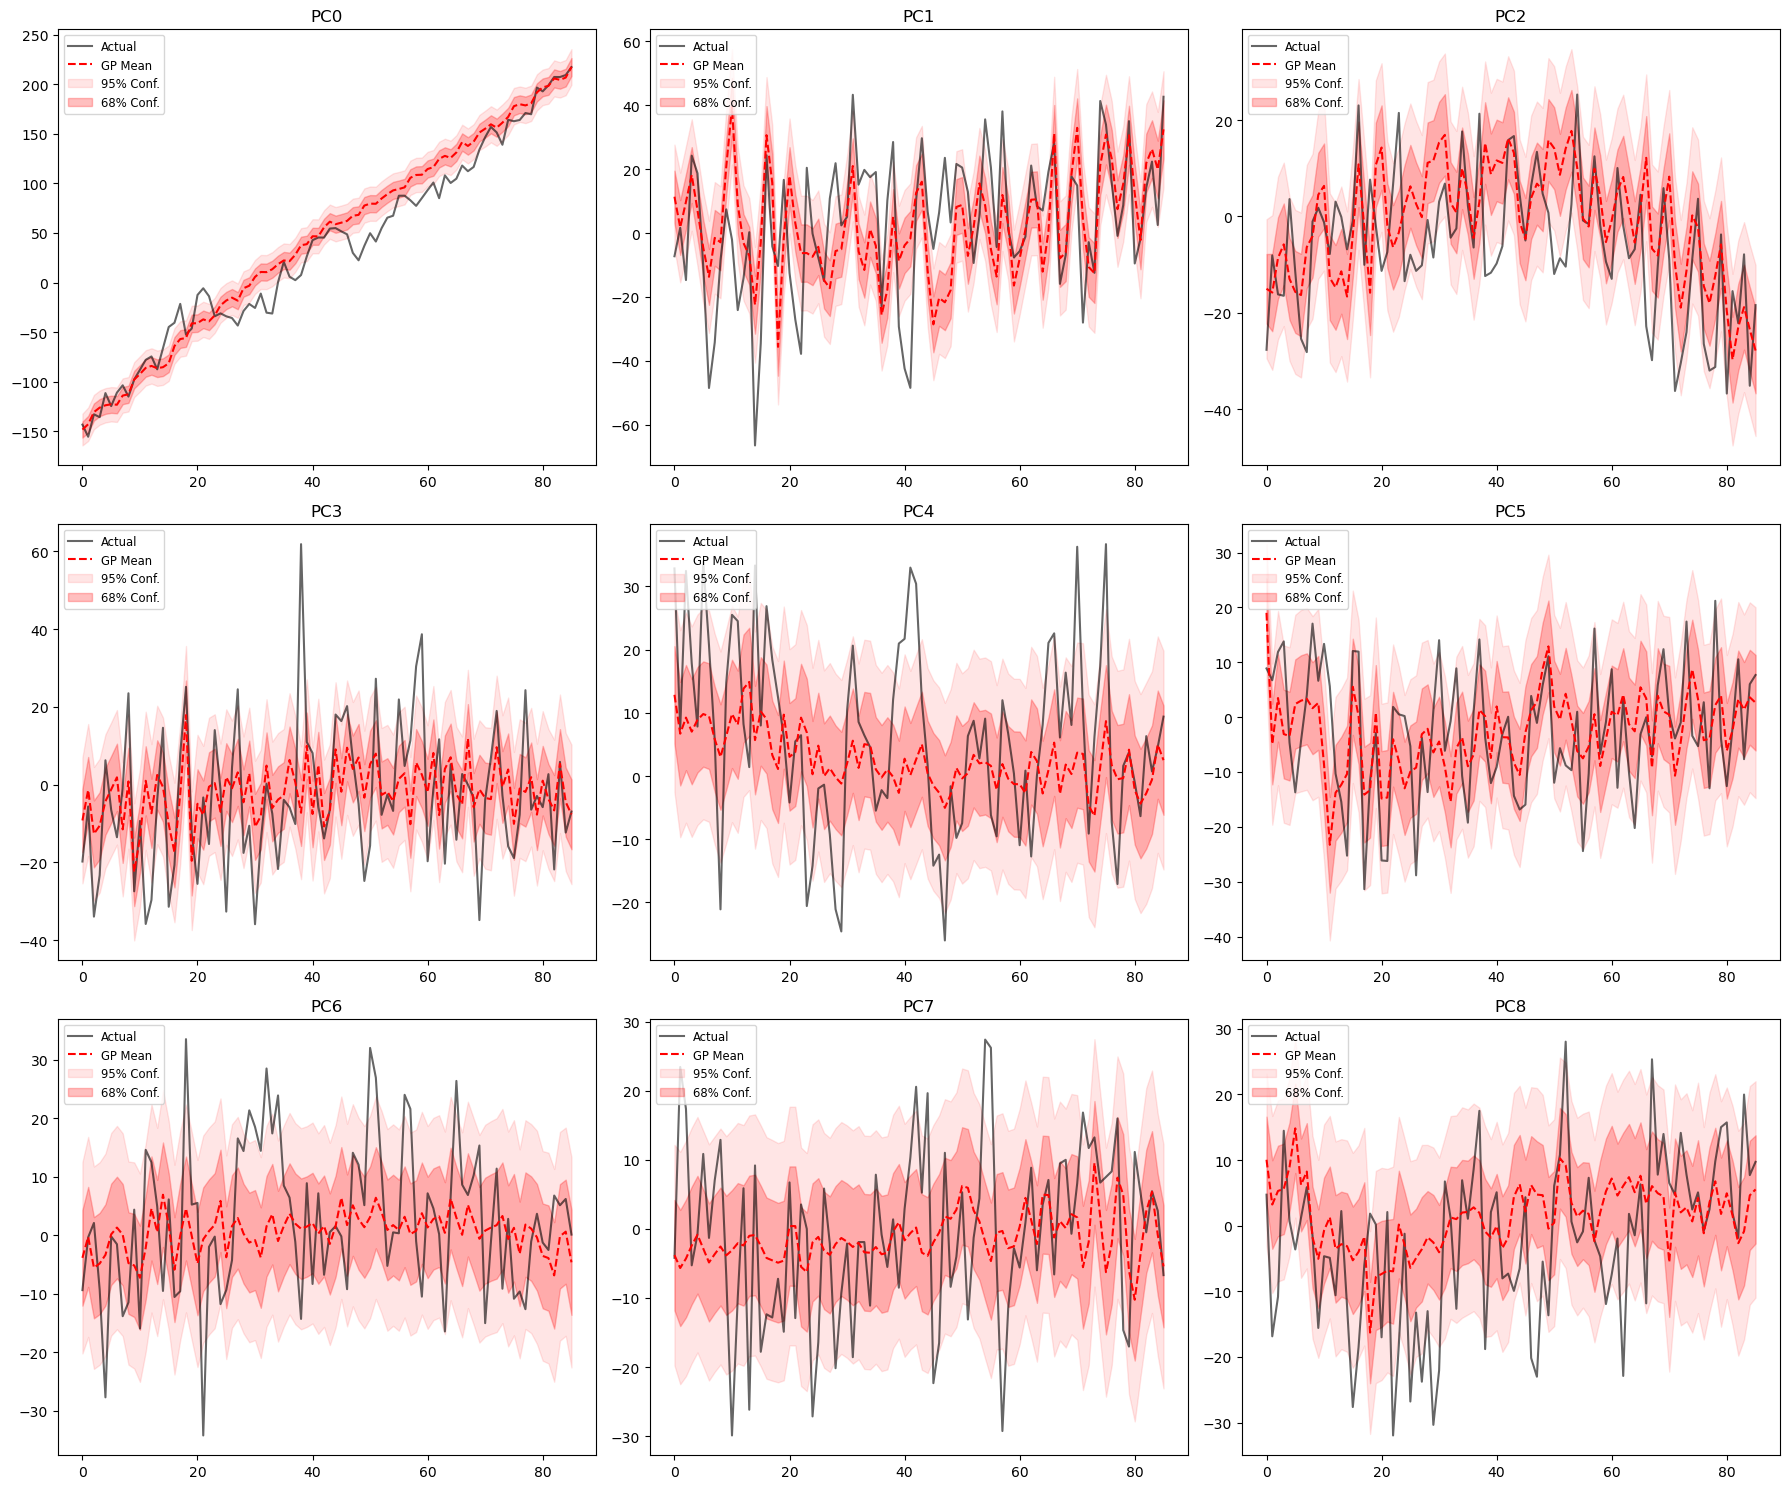

📊 True Performance Delta Range: Min = -8.26°C, Max = 0.33°C


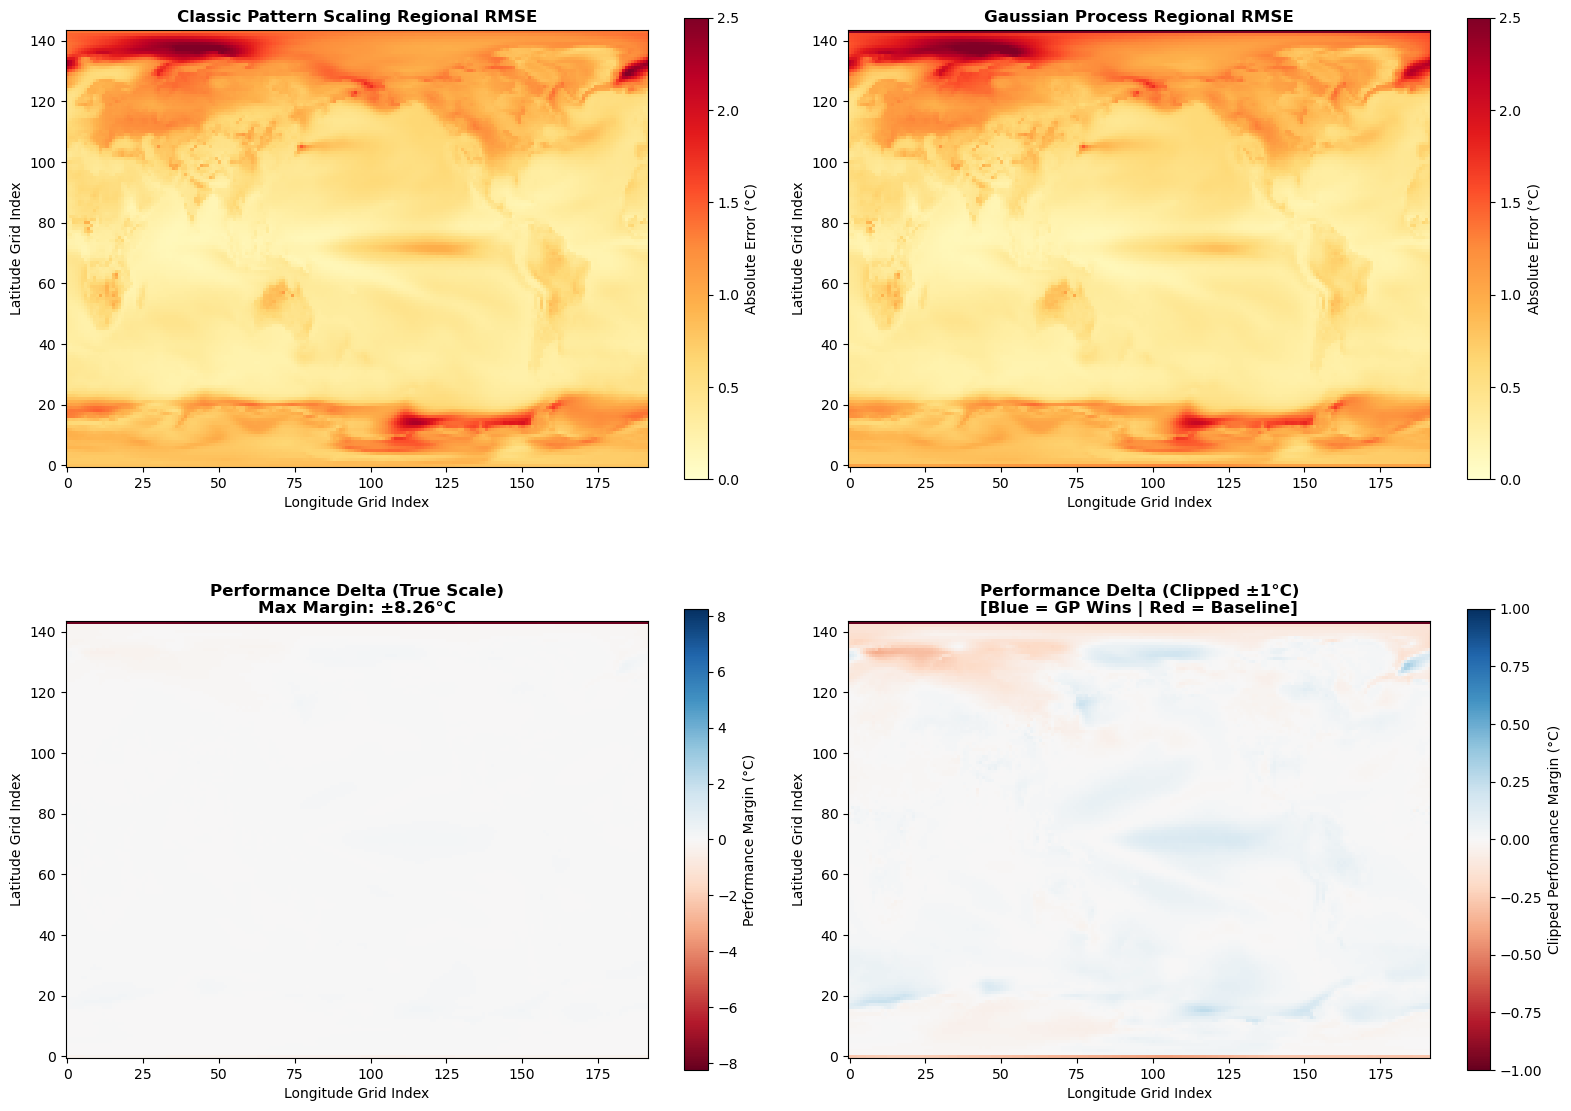

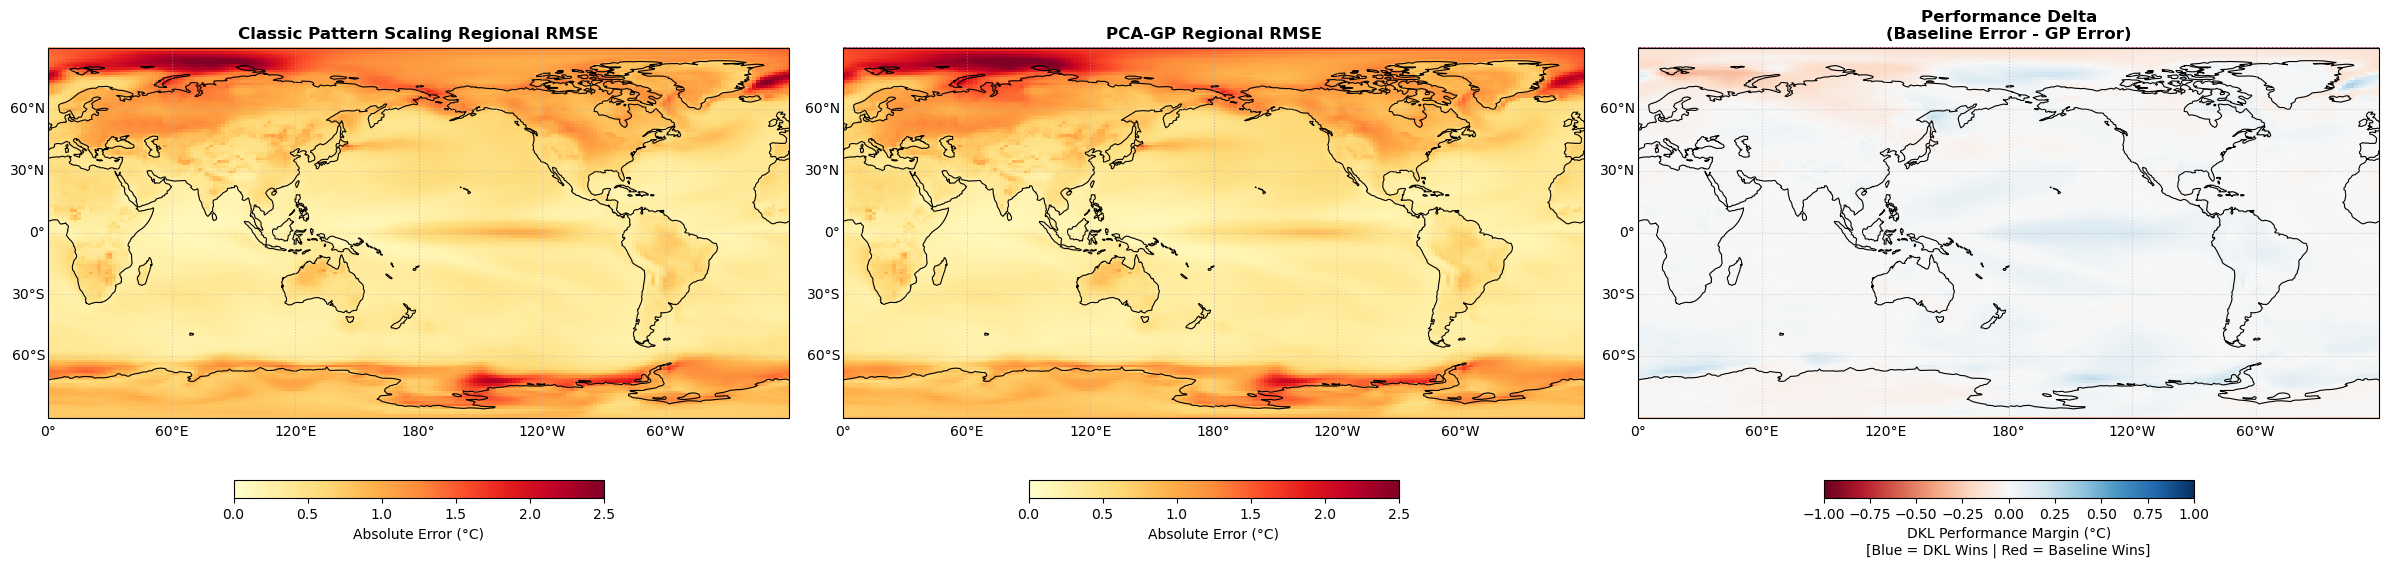

Test for dataset SSP534-os

================ TEMPORAL VALIDATION CHECK ================
Total years available in raw test dataset:  70 (2031 to 2100)
Number of lag lookback years dropped (n_lags): 10
Total valid years output for evaluation:   61
First calendar year being predicted:       2040
Last calendar year being predicted:        2100
✅ Clean separation confirmed. Test predictions start at 2040, strictly after training ended.

Prediction complete!
Unweighted Linear Pattern Scaling Baseline RMSE : 0.8835°C
📊 Number of chronological years actually evaluated: 61.00 years
Area-weighted Linear Pattern Scaling Baseline RMSE : 0.6032°C

--- Baseline Regional Evaluation Summary ---
📍 Area-weighted Baseline Arctic Spatio-Temporal RMSE: 1.9137°C
📍 Area-weighted Baseline West Antarctic Spatio-Temporal RMSE: 1.1949°C
📍 Area-weighted Baseline N.W. North America (LAND) Spatio-Temporal RMSE: 1.1596°C
📍 Area-weighted Baseline East Asia (LAND) Spatio-Temporal RMSE: 0.5900°C
📍 Area-weighted Baselin

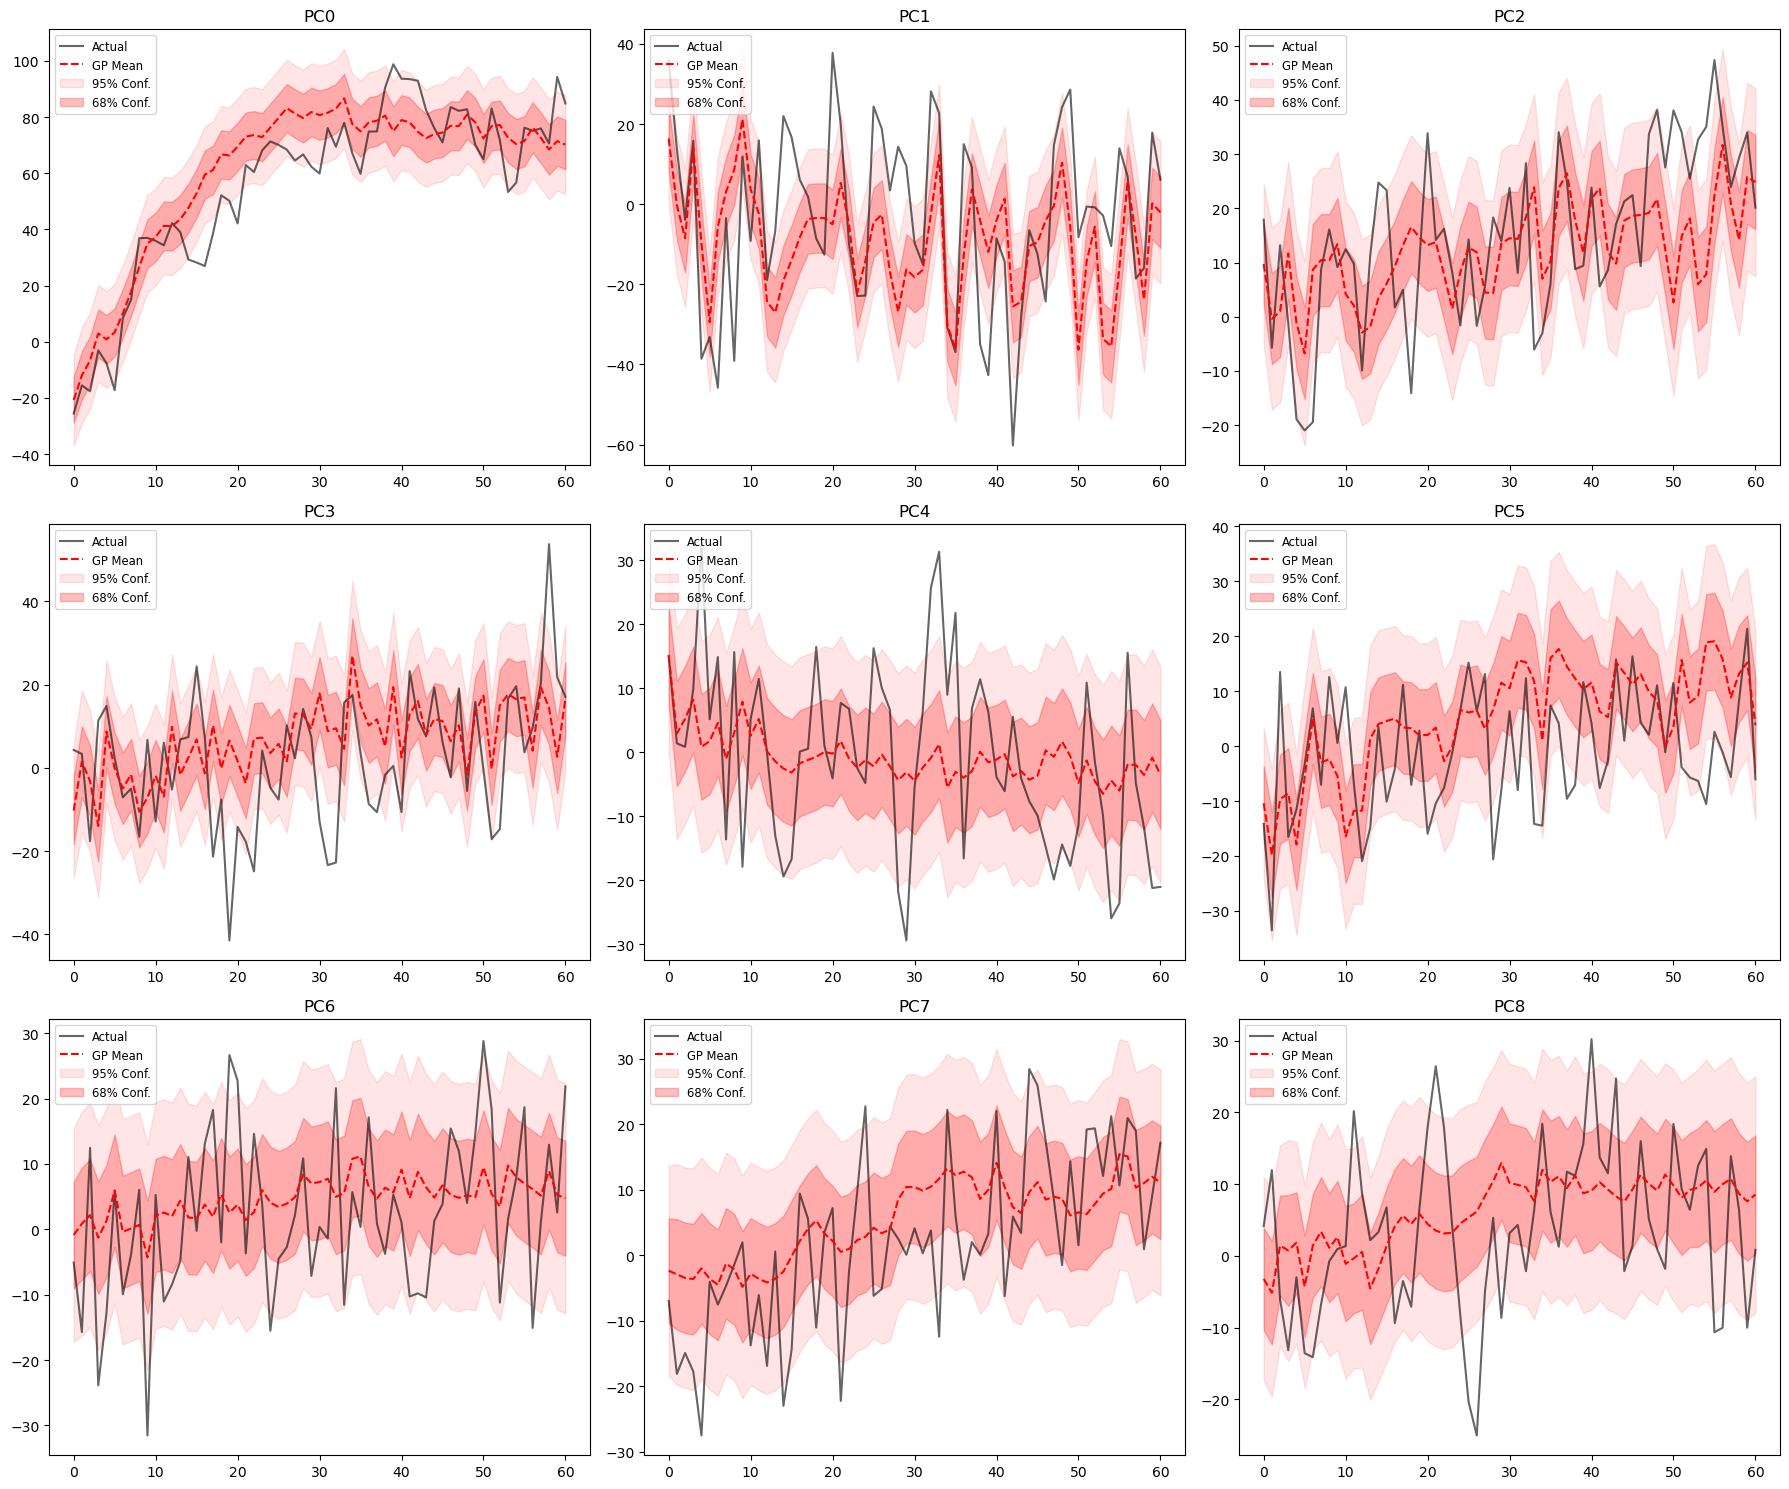

📊 True Performance Delta Range: Min = -7.86°C, Max = 1.63°C


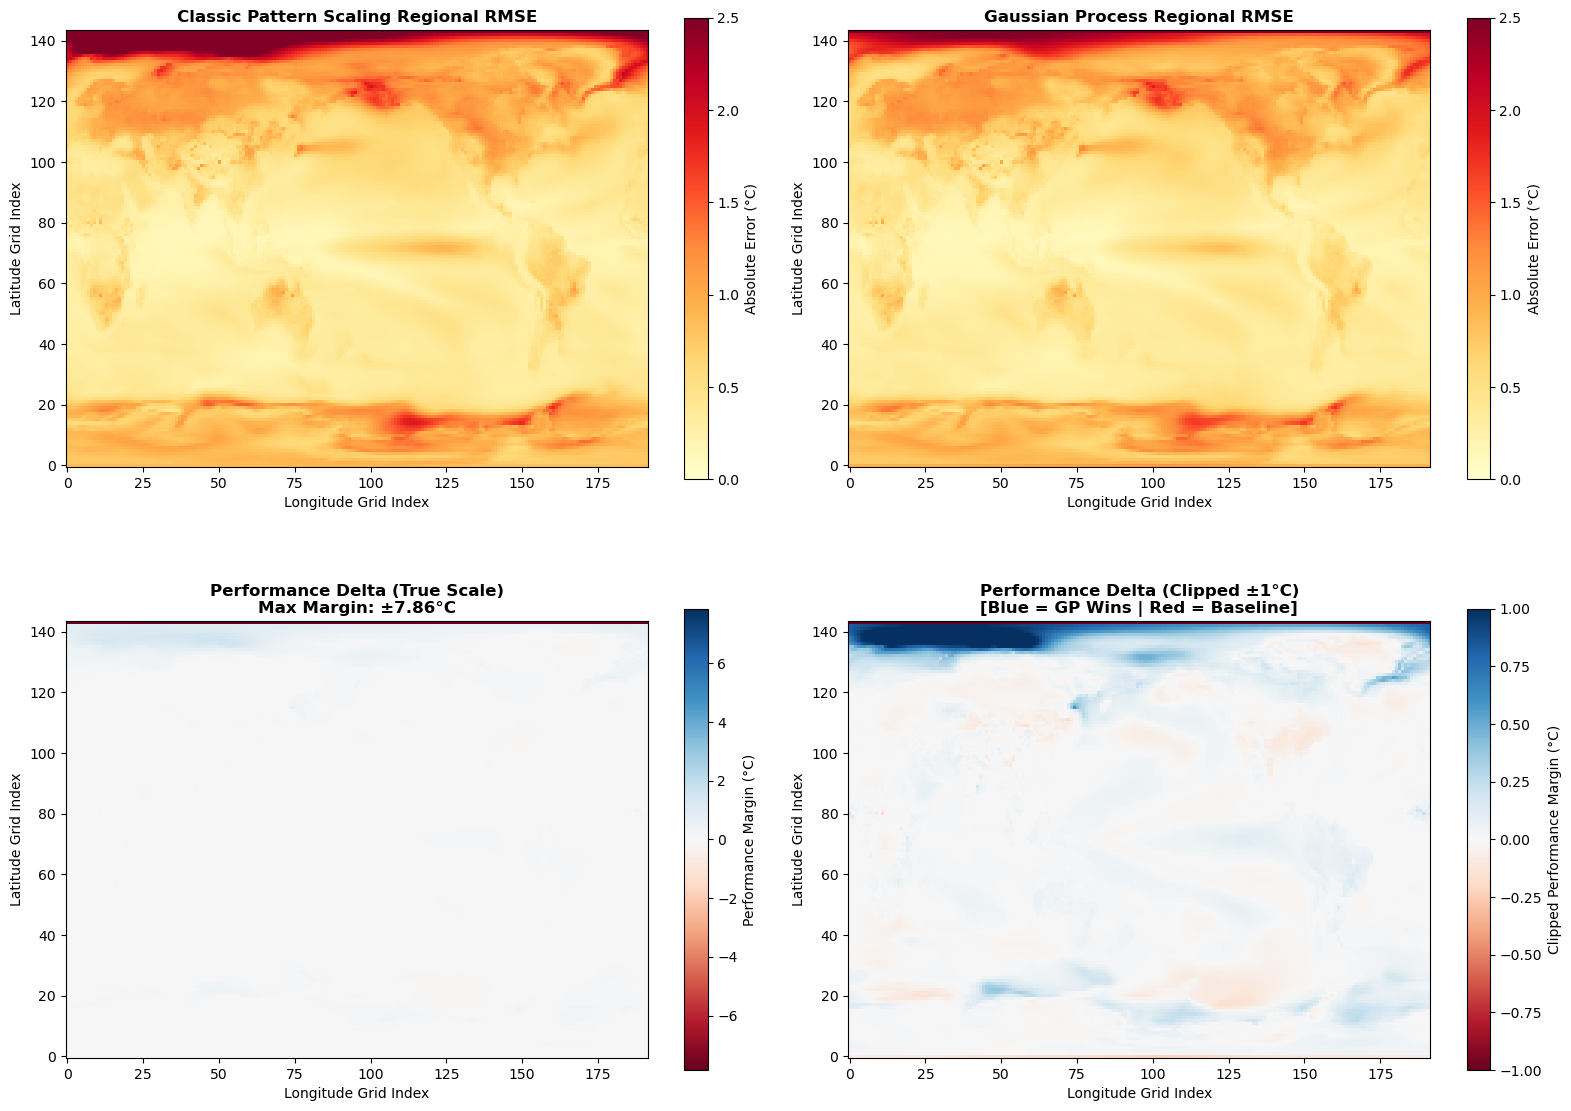

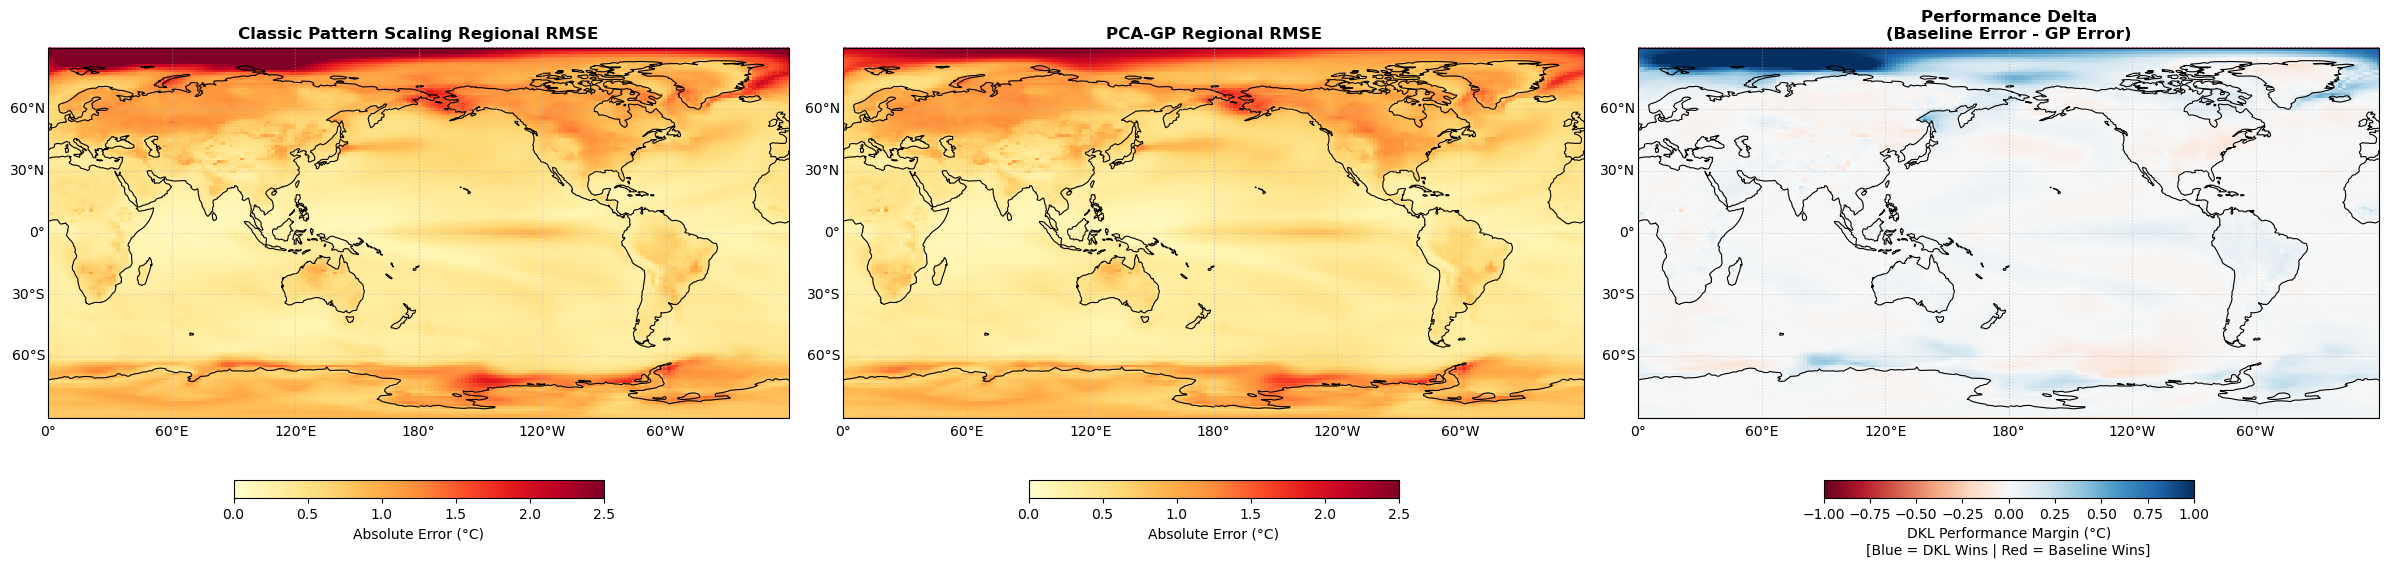

In [20]:
def test(dataset_test):
    # =========================================================
    # --- 1. PREPARE TEST DATA ---
    # =========================================================
    
    # =========================================================
    # --- AXIS REALIGNMENT FIX ---
    # =========================================================
    # Force the test dataset's latitude coordinates to be ascending (South to North).
    # This aligns the pixel row order perfectly with your training 'flat_weights'.
    if dataset_test.lat.values[0] > dataset_test.lat.values[-1]:
        dataset_test = dataset_test.sortby('lat', ascending=True)
        print("Aligned test dataset latitude orientation from South to North.")
    
    
    # FIX: Compute the unweighted global mean matching your training logic exactly
    #test_global_mean_calculated = dataset_test.tas.mean(dim=['lat', 'lon'])
    test_global_mean_calculated = dataset_test[f"tas_global"]
    
    # Extract raw global means for features
    #test_x_np = dataset_test.tas_global.values.reshape(-1, 1)
    test_x_np = dataset_test[f"tas_global"].values.reshape(-1, 1)
    
    # --- REMOVE GLOBAL TREND BEFORE TESTING PCA ---
    test_spatial_anomalies = dataset_test.tas - test_global_mean_calculated
    test_data_2d = test_spatial_anomalies.values.reshape(len(dataset_test.year), -1)
    
    # ─── UPDATED PIPELINE EXECUTION STEP ───────────────────────────────────
    # Apply the training spatial scaler first, then transform into the PC coordinate space
    test_data_2d_scaled = test_data_2d * flat_weights 
    test_y_coefs = pcas.transform(test_data_2d_scaled)
    # ───────────────────────────────────────────────────────────────────────
    
    # Feed the true coefficients directly into your lag maker (no post-PCA scaling)
    test_y_scaled = test_y_coefs
    # 1. Generate the 5-column lookback lag matrix from your raw temperature track
    test_x_lagged, test_y_sliced_scaled = build_lagged_dataset(
        test_x_np, 
        test_y_scaled, 
        n_lags=n_lags
    )
    
    # 2. Scale the 5-column matrix (Resolves the StandardScaler ValueError)
    test_x_scaled_matrix = scaler_x.transform(test_x_lagged)
    
    # 3. Convert the SCALED matrix into a PyTorch float tensor
    test_x_tensor = torch.tensor(test_x_scaled_matrix).float().to(device)
    
    # 4. Repeat across your batch dimensions for the Batch GP
    test_x_model = test_x_tensor.unsqueeze(0).repeat(num_pcs, 1, 1)
    
    # Extract unscaled ground truth targets for true physical error calculation
    valid_test_years = len(test_y_sliced_scaled)
    test_y_ground_truth = test_y_coefs[-valid_test_years:]

    # ─── TEMPORAL SANITY CHECK: TARGET YEARS VERIFICATION ─────────────────
    # Pull the real calendar years directly from your test dataset coordinate axis
    all_dataset_years = dataset_test.year.values
    
    # build_lagged_dataset naturally drops the first 'n_lags' years from the target track.
    # Therefore, the valid predicted years map to the tail end of the original years array.
    predicted_calendar_years = all_dataset_years[-valid_test_years:]
    
    print("\n================ TEMPORAL VALIDATION CHECK ================")
    print(f"Total years available in raw test dataset:  {len(all_dataset_years)} ({all_dataset_years[0]} to {all_dataset_years[-1]})")
    print(f"Number of lag lookback years dropped (n_lags): {n_lags}")
    print(f"Total valid years output for evaluation:   {valid_test_years}")
    print(f"First calendar year being predicted:       {predicted_calendar_years[0]}")
    print(f"Last calendar year being predicted:        {predicted_calendar_years[-1]}")
    
    # Emergency Warning: Update this year bound to match your training set cutoff!
    # (e.g., if your training data ended exactly at year 2039)
    training_end_year = 2039 
    if predicted_calendar_years[0] <= training_end_year:
        print(f"🚨 CRITICAL WARNING: Temporal Leak Detected!")
        print(f"Your test set is trying to predict year {predicted_calendar_years[0]}, which is <= your training limit ({training_end_year}).")
    else:
        print(f"✅ Clean separation confirmed. Test predictions start at {predicted_calendar_years[0]}, strictly after training ended.")
    print("===========================================================\n")
    
    # =========================================================
    # --- 2. PERFORM PREDICTION ---
    # =========================================================
    model.eval()
    likelihood.eval()
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        # Model returns shape: [num_pcs, Total_Valid_Test_Years]
        observed_pred = likelihood(model(test_x_model))
        
        # Extract prediction structures directly to CPU arrays
        pred_means_raw = observed_pred.mean.cpu().numpy()     # Shape: [num_pcs, Total_Valid_Test_Years]
        pred_stds_raw = observed_pred.stddev.cpu().numpy()   # Shape: [num_pcs, Total_Valid_Test_Years]
    
        # Transpose matrices natively to achieve standard format [Total_Valid_Test_Years, num_pcs]
        pred_means = pred_means_raw.T 
        pred_stds = pred_stds_raw.T
    
    # =========================================================
    # --- 3. UNSCALE THE OUTPUTS & RECONSTRUCT SPATIAL MAPS ---
    # =========================================================
    
    # --- REMOVED OLD SCALER_Y INTERACTION ENTIRELY ---
    # The coefficients are processed directly since the spatial grid was pre-scaled.
    
    # 1. Project the predicted PC coefficients back into a flat 2D spatial matrix
    pred_spatial_anomalies_scaled = pcas.inverse_transform(pred_means)
    
    # 2. INVERT THE GEOMETRIC SCALING: Divide by flat weights to recover absolute degrees C
    # Add a minor epsilon (1e-7) to prevent zero-division infinity errors at the absolute poles
    pred_spatial_anomalies_flat = pred_spatial_anomalies_scaled / (flat_weights + 1e-7)
    
    # 3. Reshape back into standard spatial grid dimensions
    pred_spatial_anomalies = pred_spatial_anomalies_flat.reshape(-1, 144, 192)
    
    
    # 4. Re-add the absolute global mean values corresponding strictly to those valid test years
    # Slice the end of test_x_np to account for lost lag years, then expand dimensions to broadcast over the grid
    test_global_means_sliced = test_x_np[-valid_test_years:].reshape(-1, 1, 1)
    
    # This yields your final physical absolute temperature map predictions!
    final_absolute_predictions = pred_spatial_anomalies + test_global_means_sliced
    
    # 5. Extract true physical ground truth absolute maps for final validation steps
    final_absolute_ground_truth = dataset_test.tas.values[-valid_test_years:]
    
    print("Prediction complete!")
    
    # =========================================================
    # --- 4. SCORING --- TODO: use AR6 region masks to set area-weights to 0 outside the specified region, then apply and get specific regional scores
    # --> for regional scores, only calculate spatio-temporal RMSE --> average over time for each grid-square, then average across the globe
    # --> overall, we still need a global rmse metric --> average over the globe and then average each global score across time
    # =========================================================
    
    
    ### PATTERN SCALING BASELINE #########################################################################
    # 1. Initialize and fit the traditional linear baseline
    # Inputs: combined_x (Total_Years, 1) -> Global Mean Anomalies
    # Targets: stacked (Total_Years, 144 * 192) -> Flat Spatial Maps
    baseline_regressor = LinearRegression()
    baseline_regressor.fit(combined_x, stacked)
    
    # 2. Predict the spatial anomaly maps for the unseen test set scenario
    # Outputs a flat spatial prediction matrix of shape (Test_Years, 144 * 192)
    baseline_pred_flat = baseline_regressor.predict(test_x_np)
    
    # 3. Reshape and re-add the absolute baseline timeline matching your test window
    # Slices the test years to align perfectly with your valid lag window
    baseline_spatial_maps = baseline_pred_flat[-valid_test_years:].reshape(-1, 144, 192)
    baseline_final_absolute_maps = baseline_spatial_maps + test_global_means_sliced

    
    # 4. Calculate the Benchmark Spatial RMSE manually using NumPy
    # (Avoids needing a separate scikit-learn metrics import)
    baseline_squared_errors = (final_absolute_ground_truth - baseline_final_absolute_maps) ** 2
    pattern_scaling_rmse = np.sqrt(np.mean(baseline_squared_errors))
    print(f"Unweighted Linear Pattern Scaling Baseline RMSE : {pattern_scaling_rmse:.4f}°C")
    
    # Reconstruct the 2D grid from the available flat_weights vector
    if (final_absolute_ground_truth.shape[1] != 27648 if final_absolute_ground_truth.ndim == 2 else final_absolute_ground_truth.shape[2] != 192):
        # Handles your ocean mask variant if applicable
        global_weight_grid_2d = np.full((144, 192), np.nan)
        global_weight_grid_2d[ocean_mask.values] = flat_weights
    else:
        global_weight_grid_2d = flat_weights.reshape(144, 192)
    #global_weight_grid_2d = flat_weights.reshape(144, 192)

    ##### Calculate the weights directly here 
    RAD_EARTH = 6.387e6
    dA_grid = compute_grid_areas(dataset_test, dataset_test['tas'].isel(year=0), x='lon', y='lat', RAD_EARTH=RAD_EARTH)
    
    # Extract the raw 2D numpy grid values
    global_weight_grid_2d = dA_grid.values
    #########################################
    
    
    # Flatten your 2D weights to match a single spatial snapshot
    global_sample_weights = global_weight_grid_2d.flatten()
    # Broadcast weights across the time dimension to match the fully flattened arrays
    #total_timesteps = baseline_final_absolute_maps.shape[0]
    total_timesteps = final_absolute_predictions.shape[0]
    multi_year_weights = np.tile(global_sample_weights, total_timesteps)
    
    # 2. Area-Weighted Baseline RMSE (Matches your new spatial_rmse_weighted)
    # Reuse the multi_year_weights array we generated earlier
    valid_baseline_mask = ~np.isnan(baseline_squared_errors.flatten()) & ~np.isnan(multi_year_weights)

    # Calculate how many total years are actually being evaluated after masking
    actual_years_evaluated = len(final_absolute_ground_truth.flatten()[valid_baseline_mask]) / (144 * 192)
    print(f"📊 Number of chronological years actually evaluated: {actual_years_evaluated:.2f} years")
    

    pattern_scaling_rmse_weighted = np.sqrt(mean_squared_error(
        final_absolute_ground_truth.flatten()[valid_baseline_mask], 
        baseline_final_absolute_maps.flatten()[valid_baseline_mask],
        sample_weight=multi_year_weights[valid_baseline_mask]
    ))
    print(f"Area-weighted Linear Pattern Scaling Baseline RMSE : {pattern_scaling_rmse_weighted:.4f}°C")

    ##### Now calculate regional scores
    # List of names matching your region_masks sequence
    region_names = [
        "Arctic", 
        "West Antarctic", 
        "N.W. North America (LAND)", 
        "East Asia (LAND)", 
        "North South America (LAND)"
    ]
    
    print("\n--- Baseline Regional Evaluation Summary ---")
    
    # Dictionary to store the baseline regional results if needed later
    baseline_regional_results = {}
    
    # Loop through each mask and calculate its specific regional Spatio-Temporal RMSE
    for name, region_mask_2d in zip(region_names, region_masks):
        
        # 1. Flatten and broadcast the 2D mask to match the multi-year time dimension
        # This creates a 1D boolean array where True is inside the target region
        multi_year_region_mask = np.tile(region_mask_2d.flatten(), total_timesteps)
        
        # 2. Combine your region mask with existing valid baseline data boundaries
        valid_baseline_region_indices = (
            multi_year_region_mask & 
            ~np.isnan(baseline_squared_errors.flatten()) & 
            ~np.isnan(multi_year_weights)
        )
        
        # 3. Extract the targeted regional pixels and matching spatial weights
        true_baseline_regional_pixels = final_absolute_ground_truth.flatten()[valid_baseline_region_indices]
        pred_baseline_regional_pixels = baseline_final_absolute_maps.flatten()[valid_baseline_region_indices]
        regional_baseline_weights = multi_year_weights[valid_baseline_region_indices]
        
        # 4. Calculate the Area-Weighted Spatio-Temporal RMSE for this specific region
        baseline_regional_rmse = np.sqrt(mean_squared_error(
            true_baseline_regional_pixels, 
            pred_baseline_regional_pixels,
            sample_weight=regional_baseline_weights
        ))
        
        # Save and display the final metric
        baseline_regional_results[name] = baseline_regional_rmse
        print(f"📍 Area-weighted Baseline {name} Spatio-Temporal RMSE: {baseline_regional_rmse:.4f}°C")
    
    #######################################################################################################
    
    # Compute real map-wide RMSE across all grid cells and years combined
    spatial_rmse = np.sqrt(mean_squared_error(
        final_absolute_ground_truth.flatten(), 
        final_absolute_predictions.flatten()
    ))
    print(f"Unweighted ML Average RMSE: {spatial_rmse:.4f}°C")

    # Handle any potential NaNs in the data or weights
    valid_indices = ~np.isnan(final_absolute_ground_truth.flatten()) & ~np.isnan(multi_year_weights)
    # Calculate Area-Weighted Global RMSE via Scikit-Learn
    spatial_rmse_weighted = np.sqrt(mean_squared_error(
        final_absolute_ground_truth.flatten()[valid_indices], 
        final_absolute_predictions.flatten()[valid_indices],
        sample_weight=multi_year_weights[valid_indices]
    ))
    print(f"Area-weighted ML Average RMSE: {spatial_rmse_weighted:.4f}°C")
    print("\n--- Machine Learning Regional Evaluation Summary ---")
    
    # Dictionary to store the ML regional results
    ml_regional_results = {}
    
    # Compute the squared errors for the ML model first
    ml_squared_errors = (final_absolute_ground_truth - final_absolute_predictions) ** 2
    
    # Loop through each mask and calculate its specific regional Spatio-Temporal RMSE
    for name, region_mask_2d in zip(region_names, region_masks):
        
        # 1. Flatten and broadcast the 2D mask to match the multi-year time dimension
        multi_year_region_mask = np.tile(region_mask_2d.flatten(), total_timesteps)
        
        # 2. Combine your region mask with existing valid ML data boundaries
        valid_ml_region_indices = (
            multi_year_region_mask & 
            ~np.isnan(ml_squared_errors.flatten()) & 
            ~np.isnan(multi_year_weights)
        )
        
        # 3. Extract the targeted regional pixels and matching spatial weights
        true_ml_regional_pixels = final_absolute_ground_truth.flatten()[valid_ml_region_indices]
        pred_ml_regional_pixels = final_absolute_predictions.flatten()[valid_ml_region_indices]
        regional_ml_weights = multi_year_weights[valid_ml_region_indices]
        
        # 4. Calculate the Area-Weighted Spatio-Temporal RMSE for this specific region
        ml_regional_rmse = np.sqrt(mean_squared_error(
            true_ml_regional_pixels, 
            pred_ml_regional_pixels,
            sample_weight=regional_ml_weights
        ))
        
        # Save and display the final metric
        ml_regional_results[name] = ml_regional_rmse
        print(f"🚀 Area-weighted ML {name} Spatio-Temporal RMSE: {ml_regional_rmse:.4f}°C")

    print("=====================")
    print("Global RMSE for both approaches (average across space before time, rather than time and then space)")
    print("------------------")
    # --- GLOBAL-MEAN RMSE CALCULATION (ENERGY CONSERVATION CHECK) ---
    
    # 1. Normalize your 2D grid areas so they sum up to 1.0 (important for accurate spatial averaging)
    # global_weight_grid_2d shape is (144, 192)
    spatial_weights_normalized = global_weight_grid_2d / np.nansum(global_weight_grid_2d)
    
    # 2. Compute the True Area-Weighted Global Mean Timeline
    # We multiply each year's 2D map by the normalized weights and sum over the lat/lon axes (1, 2)
    true_global_mean_timeline = np.nansum(final_absolute_ground_truth * spatial_weights_normalized, axis=(1, 2))
    
    # 3. Compute the Baseline Area-Weighted Global Mean Timeline
    baseline_global_mean_timeline = np.nansum(baseline_final_absolute_maps * spatial_weights_normalized, axis=(1, 2))
    
    # 4. Compute the Machine Learning Area-Weighted Global Mean Timeline
    ml_global_mean_timeline = np.nansum(final_absolute_predictions * spatial_weights_normalized, axis=(1, 2))
    
    
    # 5. Calculate the Temporal RMSE across years between the collapsed timelines
    global_mean_baseline_rmse = np.sqrt(mean_squared_error(
        true_global_mean_timeline, 
        baseline_global_mean_timeline
    ))
    
    global_mean_ml_rmse = np.sqrt(mean_squared_error(
        true_global_mean_timeline, 
        ml_global_mean_timeline
    ))
    
    print(f"📉 True Global-Mean Baseline RMSE over Time : {global_mean_baseline_rmse:.4f}°C")
    print(f"📉 True Global-Mean ML Model RMSE over Time  : {global_mean_ml_rmse:.4f}°C")
    print("==================================================")

    
    
    """
    ===> SAVE final_absolute_predictions, final_absolute_ground_truth, baseline_final_absolute_maps to pandas or something for access later
    """
    save = False
    if save:
        target_dir = "cnn-gp-outputs"
        metric = 'tas'
        save_path_nc = os.path.join(target_dir, f"pure_gp_eval_{metric}.nc")
        
        # 1. Grab matching coordinates directly from your test set slice
        test_slice = dataset_test.isel(year=slice(-valid_test_years, None))
        
        # 2. Build a beautifully labeled multi-variable xarray dataset
        eval_dataset = xr.Dataset(
            data_vars={
                "ground_truth": (["year", "lat", "lon"], final_absolute_ground_truth),
                "dkl_prediction": (["year", "lat", "lon"], final_absolute_predictions),
                "pattern_scaling_prediction": (["year", "lat", "lon"], baseline_final_absolute_maps)
            },
            coords={
                "year": test_slice.year.values,
                "lat": test_slice.lat.values,
                "lon": test_slice.lon.values
            }
        )
        
        # 3. Export cleanly as a standard climate modeling NetCDF file
        eval_dataset.to_netcdf(save_path_nc)
        print(xr.open_dataset(save_path_nc)) # Open to verify coordinates and attributes
    """
    ===> End of saving preds and ground truth to xarray
    """


    
    
    print("Metrics relating to PCA:")
    # Evaluate prediction matrices against unscaled ground truth coefficients
    rmse = np.sqrt(mean_squared_error(test_y_ground_truth, pred_means))
    r2 = r2_score(test_y_ground_truth, pred_means)
    
    print(f"Total Test RMSE: {rmse:.4f}")
    print(f"Total Test R² Score: {r2:.4f}")
    
    # Calculate individual PC errors
    pc_errors = []
    for i in range(test_y_ground_truth.shape[1]):
        err = np.sqrt(mean_squared_error(test_y_ground_truth[:, i], pred_means[:, i]))
        pc_errors.append(err)
    
    error_df = pd.DataFrame({
        'PC': [f'PC{i}' for i in range(len(pc_errors))],
        'RMSE': pc_errors
    })
    print(error_df)
    
    # =========================================================
    # --- 5. PLOTTING ---
    # =========================================================
    n_pcs = pcas.n_components_
    cols = 3
    rows = int(np.ceil(n_pcs / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten()
    
    for i in range(n_pcs):
        x_range = np.arange(len(pred_means))
        
        # Update ground truth array reference to use sliced target index maps
        axes[i].plot(test_y_ground_truth[:, i], 'k-', label='Actual', alpha=0.6)
        axes[i].plot(pred_means[:, i], 'r--', label='GP Mean', linewidth=1.5)
    
        # Shading for 2 STD (95% Confidence)
        lower_2std = pred_means[:, i] - 2 * pred_stds[:, i]
        upper_2std = pred_means[:, i] + 2 * pred_stds[:, i]
        axes[i].fill_between(x_range, lower_2std, upper_2std, 
                             color='red', alpha=0.1, label='95% Conf.')
    
        # Shading for 1 STD (68% Confidence)
        lower_1std = pred_means[:, i] - 1 * pred_stds[:, i]
        upper_1std = pred_means[:, i] + 1 * pred_stds[:, i]
        axes[i].fill_between(x_range, lower_1std, upper_1std, 
                             color='red', alpha=0.25, label='68% Conf.')
    
        axes[i].set_title(f'PC{i}')
        axes[i].legend(loc='upper left', fontsize='small')
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

    # =========================================================
    # --- 6. REGIONAL MAP ERROR HEATMAPS (2x2 GRID) ---
    # =========================================================
    
    # 1. Compute pixel-wise RMSE over time (axis=0) using your exact array blocks
    baseline_pixel_rmse = np.sqrt(np.mean((final_absolute_ground_truth - baseline_final_absolute_maps) ** 2, axis=0))
    gp_pixel_rmse = np.sqrt(np.mean((final_absolute_ground_truth - final_absolute_predictions) ** 2, axis=0))
    
    # 2. Compute Direct Performance Comparison Map (Difference Map)
    error_difference = baseline_pixel_rmse - gp_pixel_rmse
    
    # ─── DYNAMIC COLORBAR BOUNDARY CALCULATION ────────────────────────────
    true_min = np.nanmin(error_difference)
    true_max = np.nanmax(error_difference)
    abs_max_limit = max(abs(true_min), abs(true_max))
    
    print(f"📊 True Performance Delta Range: Min = {true_min:.2f}°C, Max = {true_max:.2f}°C")
    # ───────────────────────────────────────────────────────────────────────
    
    # 3. Render 2x2 geographic heatmaps
    # Matrix dimensions change to 2 rows and 2 columns
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # ─── TOP ROW: ABSOLUTE ERRORS ─────────────────────────────────────────
    # Top-Left: Classic Linear Pattern Scaling Error Grid
    im0 = axes[0, 0].imshow(baseline_pixel_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=2.5)
    axes[0, 0].set_title('Classic Pattern Scaling Regional RMSE', fontweight='bold', fontsize=12)
    fig.colorbar(im0, ax=axes[0, 0], label='Absolute Error (°C)', shrink=0.8)
    
    # Top-Right: Gaussian Process Model Error Grid
    im1 = axes[0, 1].imshow(gp_pixel_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=2.5)
    axes[0, 1].set_title('Gaussian Process Regional RMSE', fontweight='bold', fontsize=12)
    fig.colorbar(im1, ax=axes[0, 1], label='Absolute Error (°C)', shrink=0.8)

    np.savez("EO/baseline_and_gps", baseline=baseline_pixel_rmse, gp=gp_pixel_rmse)
    
    # ─── BOTTOM ROW: PERFORMANCE DELTAS ───────────────────────────────────
    # Bottom-Left: Performance Delta Grid (UNCAPPED TRUE RANGE VERSION)
    im2 = axes[1, 0].imshow(error_difference, cmap='RdBu', origin='lower', vmin=-abs_max_limit, vmax=abs_max_limit)
    axes[1, 0].set_title(f'Performance Delta (True Scale)\nMax Margin: ±{abs_max_limit:.2f}°C', fontweight='bold', fontsize=12)
    fig.colorbar(im2, ax=axes[1, 0], label='Performance Margin (°C)', shrink=0.8)

    # Bottom-Right: Performance Delta Grid (ZOOMED/CLIPPED REGIONAL VERSION)
    im3 = axes[1, 1].imshow(error_difference, cmap='RdBu', origin='lower', vmin=-1.0, vmax=1.0)
    axes[1, 1].set_title('Performance Delta (Clipped ±1°C)\n[Blue = GP Wins | Red = Baseline]', fontweight='bold', fontsize=12)
    fig.colorbar(im3, ax=axes[1, 1], label='Clipped Performance Margin (°C)', shrink=0.8)
    
    # Add standardized layout descriptions to all four coordinate quadrants
    # Use axes.flatten() to cycle safely through the 2D matrix view
    for ax in axes.flatten():
        ax.set_xlabel('Longitude Grid Index')
        ax.set_ylabel('Latitude Grid Index')
    
    plt.tight_layout()
    plt.show()
    ###### add coastlines in cartopy
    vmax_error = 2.5
    vmax_delta = 1.0
    vmin_delta = -1.0
    cbar_label = 'Absolute Error (°C)'
    delta_label = 'DKL Performance Margin (°C)\n[Blue = DKL Wins | Red = Baseline Wins]'
    fmt_cbar = None  # Standard linear colorbar labels
    # 1. FIX: Adjust longitudes to match your raw 0-360 degree data range
    lats = np.linspace(-90, 90, baseline_pixel_rmse.shape[0])
    lons = np.linspace(0, 360, baseline_pixel_rmse.shape[1])
    
    # 2. FIX: Tell Cartopy to center the visual canvas on the Pacific (180 degrees)
    # We keep the transform as standard PlateCarree() because the underlying data coordinates match it.
    fig, axes = plt.subplots(
        1, 3, 
        figsize=(24, 8), 
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
    )
    
    # --- Render Plot 1: Classic Pattern Scaling Map ---
    im0 = axes[0].pcolormesh(lons, lats, baseline_pixel_rmse, cmap='YlOrRd', vmin=0, vmax=2.5, transform=ccrs.PlateCarree())
    axes[0].set_title('Classic Pattern Scaling Regional RMSE', fontweight='bold', fontsize=12)
    cbar0 = fig.colorbar(im0, ax=axes[0], label=cbar_label, shrink=0.5, format=fmt_cbar, orientation='horizontal', pad=0.08)
    
    # --- Render Plot 2: Deep Kernel Learning Map ---
    im1 = axes[1].pcolormesh(lons, lats, gp_pixel_rmse, cmap='YlOrRd', vmin=0, vmax=2.5, transform=ccrs.PlateCarree())
    axes[1].set_title('PCA-GP Regional RMSE', fontweight='bold', fontsize=12)
    cbar1 = fig.colorbar(im1, ax=axes[1], label=cbar_label, shrink=0.5, format=fmt_cbar, orientation='horizontal', pad=0.08)
    
    # --- Render Plot 3: Performance Variance Difference Map ---
    im2 = axes[2].pcolormesh(lons, lats, error_difference, cmap='RdBu', vmin=-1.0, vmax=1.0, transform=ccrs.PlateCarree())
    axes[2].set_title('Performance Delta\n(Baseline Error - GP Error)', fontweight='bold', fontsize=12)
    cbar2 = fig.colorbar(im2, ax=axes[2], label=delta_label, shrink=0.5, format=fmt_cbar, orientation='horizontal', pad=0.08)
    
    # Apply standard spatial labels and coastlines across all axes
    for ax in axes:
        ax.coastlines(resolution='110m', color='black', linewidth=0.8)
        
        # 1. REMOVE these lines as Cartopy blocks them:
        # ax.set_xlabel('Longitude (degrees)')
        # ax.set_ylabel('Latitude (degrees)')
        
        # 2. FIX: Enable labels via gridlines and configure their styling
        gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        
        # Add your axis titles to the gridlines directly
        gl.bottom_labels = True
        gl.left_labels = True
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}
        
    plt.tight_layout()
    plt.show()


    #########






## TESTS ##
print(f"DEBUG - Validation Set Start Year: {validation_set.year.values[0]}")
print(f"DEBUG - Validation Set Total Years: {len(validation_set.year.values)}")
print("====================\nTest for dataset SSP37O\n============")
test(validation_set)
print("Test for dataset SSP534-os\n================")
test(dataset_test)


In [ ]:
"""
target_year_idx = 20

# Remap explicitly to your active PC variable size (e.g., 29)
num_pcs = pcas.n_components_
test_x_batched = test_x_tensor.unsqueeze(0).repeat(num_pcs, 1, 1)

model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # observed_pred.mean shape is [29, Total_Valid_Test_Years]
    observed_pred = likelihood(model(test_x_batched))
    
    # Transpose the matrix to swap [29, Years] into the [Years, 29] format expected by Scikit-Learn
    test_pred_coeffs = observed_pred.mean.t().cpu().numpy()

# Determine total valid steps after removing lag buffers
valid_test_years = len(test_pred_coeffs)

# =================================================================
# 1. FIXED TEMPORAL COORDINATE ALIGNMENT (THE CORES OF THE RESET)
# =================================================================
# Create temporally synchronized arrays matching the valid lag window exactly
synchronized_tas_grid = dataset_test.tas.values[-valid_test_years:]
synchronized_years = dataset_test.year.values[-valid_test_years:]
synchronized_global_means_raw = dataset_test.tas_global.values[-valid_test_years:]

# Extract the identical index slice from your un-lagged global feature array 
# This prevents the baseline model from displaying an offset calendar year!
synchronized_test_x_np = test_x_np[-valid_test_years:]

# Gather absolute identifiers for this specific target frame
target_year_global_mean = synchronized_global_means_raw[target_year_idx]
actual_map = synchronized_tas_grid[target_year_idx]
target_year_val = synchronized_years[target_year_idx]

# =================================================================
# 2. GAUSSIAN PROCESS MAP RECONSTRUCTION
# =================================================================
# target_pred_coeffs shape: [1, 29]
target_pred_coeffs = test_pred_coeffs[target_year_idx : target_year_idx + 1]

# Reconstruct the raw spatial anomaly map from the coefficients -> Shape: (144, 192)
reconstructed_spatial_anomaly_scaled = pcas.inverse_transform(target_pred_coeffs).reshape(144, 192)

# INVERT GEOMETRIC SCALING: Divide out the flat area weights to get physical degrees C
reconstructed_spatial_anomaly = reconstructed_spatial_anomaly_scaled / (flat_weights.reshape(144, 192) + 1e-7)

# Add the scalar global warming trend baseline directly back to the spatial pattern matrix
reconstructed_map = reconstructed_spatial_anomaly + target_year_global_mean

# =================================================================
# 3. BASELINE RECONSTRUCTION FOR THE SPECIFIC TARGET YEAR
# =================================================================
# Use the fitted baseline regressor to predict the raw flat spatial field using the synchronized input vector
target_year_baseline_flat = baseline_regressor.predict(synchronized_test_x_np[target_year_idx : target_year_idx + 1])

# Reshape back into 2D spatial grid dimensions -> Shape: (144, 192)
baseline_spatial_anomaly = target_year_baseline_flat.reshape(144, 192)

# Add the scalar global warming trend baseline matching the target year exactly
reconstructed_baseline_map = baseline_spatial_anomaly + target_year_global_mean

# =================================================================
# 4. RENDER TRIPLE DIAGNOSTIC VISUALIZATION
# =================================================================
# Setup 1 row with 3 columns to place maps back-to-back
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Frame 1: Actual Ground Truth Map
im1 = axes[0].imshow(actual_map, cmap='RdBu_r', origin='lower', vmin=-2, vmax=10)
axes[0].set_title(f'Actual Anomaly (Year {target_year_val})', fontweight='bold')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Temperature (°C)')

# Frame 2: Classic Linear Pattern Scaling Projection
im2 = axes[1].imshow(reconstructed_baseline_map, cmap='RdBu_r', origin='lower', vmin=-2, vmax=10)
axes[1].set_title(f'Linear Pattern Scaling Prediction (Year {target_year_val})', fontweight='bold')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Temperature (°C)')

# Frame 3: Your Lagged Gaussian Process Prediction
im3 = axes[2].imshow(reconstructed_map, cmap='RdBu_r', origin='lower', vmin=-2, vmax=10)
axes[2].set_title(f'GP Predicted Anomaly (Year {target_year_val})', fontweight='bold')
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04, label='Temperature (°C)')

# Layout labels for clear geographical orientation
for ax in axes:
    ax.set_xlabel('Longitude Grid Index')
    ax.set_ylabel('Latitude Grid Index')

plt.tight_layout()
plt.show()
"""

In [ ]:
#!pip freeze > requirements.txt